# BVAR Mechanics Notebook

This notebook extends the previous VAR notebook by replacing classical point estimation with Bayesian estimation.

The goal is to understand the implementation details of Bayesian VARs before introducing any distributionally robust optimization or diffusion-based residual modeling.

We will work in a controlled setting using simulated data, so that the true data-generating process is known and estimation behavior can be checked directly.

## Main goals

This notebook will cover:

1. Implement a Bayesian VAR with a Normal-Inverse-Wishart prior
2. Implement a Bayesian VAR with a Minnesota prior
3. Draw posterior samples for coefficients and covariance matrices
4. Verify posterior sampling using trace plots and effective sample size
5. Generate posterior predictive forecasts
6. Construct predictive intervals
7. Run rolling forecast experiments
8. Evaluate forecast performance using:
   - RMSE
   - MAE
   - predictive interval coverage
   - log predictive density
9. Check stability, stationarity, and forecast reproducibility
10. Save experiment summaries and exported model objects

## Modeling setup

As in the VAR notebook, we work with the multivariate regression form of a VAR$(p)$:

$
Y = X B + U
$

where

- $Y$ is the response matrix
- $X$ is the lagged design matrix
- $B$ is the coefficient matrix
- $U$ is the innovation matrix

The difference is that now $B$ and the innovation covariance matrix $\Sigma$ are treated as random objects with prior distributions.

## Workflow for this notebook

We proceed in the following order:

1. Recreate the simulated stable VAR dataset
2. Fit an OLS VAR benchmark
3. Build the Normal-Inverse-Wishart BVAR
4. Check posterior draws and diagnostics
5. Build the Minnesota-prior BVAR
6. Compare forecasts across methods

This notebook is only about the **Bayesian mechanics**. We are not yet introducing:

- distributionally robust optimization
- diffusion models
- structural shock identification
- stochastic volatility

Those will come later, after the Bayesian forecasting pipeline is fully understood.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle

from pathlib import Path
from datetime import datetime

from scipy.stats import invwishart, multivariate_normal, norm

# Optional diagnostics package
try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

# -----------------------------------------------------------------------------
# Global reproducibility
# -----------------------------------------------------------------------------
GLOBAL_SEED = 123
rng = np.random.default_rng(GLOBAL_SEED)

print("=" * 80)
print("BVAR MECHANICS NOTEBOOK SETUP")
print("=" * 80)
print(f"Global seed: {GLOBAL_SEED}")
print(f"ArviZ available: {ARVIZ_AVAILABLE}")
print()

# -----------------------------------------------------------------------------
# Plot settings
# -----------------------------------------------------------------------------
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Imports loaded successfully.")
print("Ready to define helper functions and simulate data.")

BVAR MECHANICS NOTEBOOK SETUP
Global seed: 123
ArviZ available: True

Imports loaded successfully.
Ready to define helper functions and simulate data.


## Reusable VAR Utilities and Simulated Data

To keep the Bayesian notebook parallel to the previous VAR notebook, we first recreate the core helper functions needed for:

- companion-matrix construction
- stability checking
- VAR simulation
- regression-matrix construction
- multi-step forecasting

We then simulate a stable VAR$(2)$ dataset, which will be used throughout the notebook for:

- OLS benchmarking
- NIW BVAR estimation
- Minnesota-prior BVAR estimation
- posterior predictive forecasting

Using simulated data is important because the true coefficient matrices and innovation covariance are known, so posterior recovery can be checked directly.

SIMULATED DATA SETUP
Stable VAR: True
Max eigenvalue modulus: 0.4650
Simulated data shape: (300, 3)


,y1,y2,y3
time,,,
0,0.551738,-0.703764,0.380809
1,-1.110253,-2.564039,-1.328354
2,-1.040441,-0.507790,0.476514
3,-0.627772,-1.469973,-0.671117
4,-0.288088,-0.916778,-0.020670


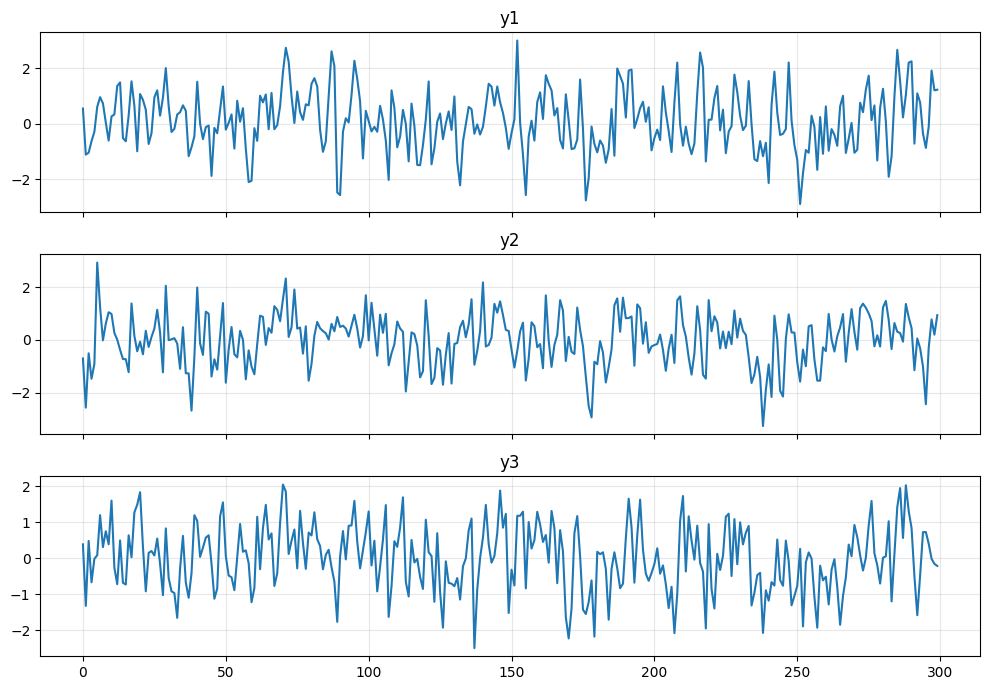

In [2]:
# -----------------------------------------------------------------------------
# Core VAR helper functions reused in the BVAR notebook
# -----------------------------------------------------------------------------
def companion_matrix(A_list):
    p = len(A_list)
    k = A_list[0].shape[0]

    top_block = np.hstack(A_list)

    if p == 1:
        return top_block

    lower_block = np.hstack([
        np.eye(k * (p - 1)),
        np.zeros((k * (p - 1), k))
    ])

    return np.vstack([top_block, lower_block])


def is_var_stable(A_list, tol=0.999):
    F = companion_matrix(A_list)
    eigvals = np.linalg.eigvals(F)
    max_modulus = np.max(np.abs(eigvals))
    return max_modulus < tol, max_modulus, eigvals


def simulate_var(A_list, Sigma, T, burnin=200, seed=123):
    local_rng = np.random.default_rng(seed)

    p = len(A_list)
    k = A_list[0].shape[0]
    total_T = T + burnin

    Y = np.zeros((total_T + p, k))
    shocks = local_rng.multivariate_normal(
        mean=np.zeros(k),
        cov=Sigma,
        size=total_T
    )

    for t in range(p, total_T + p):
        y_t = np.zeros(k)

        for lag in range(1, p + 1):
            y_t += A_list[lag - 1] @ Y[t - lag]

        y_t += shocks[t - p]
        Y[t] = y_t

    return Y[p + burnin:]


def build_var_regression_matrices(Y, p, include_intercept=True):
    Y = np.asarray(Y)
    T, k = Y.shape

    if T <= p:
        raise ValueError(f"Need T > p, but got T={T}, p={p}")

    X_rows = []
    Y_rows = []
    feature_names = []

    if include_intercept:
        feature_names.append("const")

    for lag in range(1, p + 1):
        for j in range(k):
            feature_names.append(f"y{j+1}_lag{lag}")

    for t in range(p, T):
        row = []

        if include_intercept:
            row.append(1.0)

        for lag in range(1, p + 1):
            row.extend(Y[t - lag, :])

        X_rows.append(row)
        Y_rows.append(Y[t, :])

    X = np.array(X_rows)
    Y_target = np.array(Y_rows)

    return Y_target, X, feature_names


def extract_var_coefficients(B, k, p, include_intercept=True):
    row_idx = 0
    intercept = None

    if include_intercept:
        intercept = B[0, :]
        row_idx = 1

    A_list = []
    for lag in range(p):
        block = B[row_idx + lag * k : row_idx + (lag + 1) * k, :]
        A_list.append(block.T)

    return intercept, A_list


def var_forecast(A_list, intercept, y_history, h):
    p = len(A_list)
    k = A_list[0].shape[0]

    if y_history.shape != (p, k):
        raise ValueError(f"y_history must have shape {(p, k)}, got {y_history.shape}")

    const = np.zeros(k) if intercept is None else intercept.copy()
    history = [row.copy() for row in y_history]
    forecasts = []

    for _ in range(h):
        y_next = const.copy()
        for lag in range(1, p + 1):
            y_next += A_list[lag - 1] @ history[-lag]
        forecasts.append(y_next)
        history.append(y_next)

    return np.array(forecasts)


# -----------------------------------------------------------------------------
# Simulate stable VAR(2) data
# -----------------------------------------------------------------------------
k = 3
p = 2
T = 300

A1 = np.array([
    [0.50, 0.10, 0.00],
    [0.05, 0.40, 0.10],
    [0.00, 0.10, 0.35]
])

A2 = np.array([
    [-0.20, 0.00, 0.05],
    [0.00, -0.15, 0.00],
    [0.05, 0.00, -0.10]
])

Sigma = np.array([
    [1.00, 0.30, 0.20],
    [0.30, 0.80, 0.25],
    [0.20, 0.25, 0.60]
])

stable, max_modulus, eigvals = is_var_stable([A1, A2])

print("=" * 80)
print("SIMULATED DATA SETUP")
print("=" * 80)
print(f"Stable VAR: {stable}")
print(f"Max eigenvalue modulus: {max_modulus:.4f}")

if not stable:
    raise ValueError("Chosen DGP is not stable.")

Y = simulate_var([A1, A2], Sigma, T=T, burnin=300, seed=GLOBAL_SEED)

columns = [f"y{i+1}" for i in range(k)]
df = pd.DataFrame(Y, columns=columns)
df.index.name = "time"

print(f"Simulated data shape: {df.shape}")
display(df.head())

fig, axes = plt.subplots(k, 1, figsize=(10, 7), sharex=True)

for i, col in enumerate(columns):
    axes[i].plot(df.index, df[col])
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## OLS VAR Benchmark

Before implementing Bayesian estimation, it is useful to fit the classical VAR by multivariate OLS again.

This gives a deterministic benchmark for:

- coefficient recovery
- estimated innovation covariance
- stability of the fitted system
- later comparison against NIW and Minnesota BVARs

The VAR is estimated in regression form:

$
Y = X B + U
$

with OLS estimator

$
\hat{B} = (X'X)^{-1} X'Y
$

From $\hat{B}$ we recover:

- the intercept vector
- the lag coefficient matrices $A_1, \dots, A_p$
- residuals and $\hat{\Sigma}$

This benchmark helps separate:

- what comes from the underlying data and regression setup
- what changes once Bayesian priors and posterior sampling are introduced

OLS VAR BENCHMARK
Number of variables: 3
Lag order: 2
Effective sample size: 298

Estimated intercept:
[ 0.1056 -0.0068  0.0034]

Estimated A1:
[[0.39   0.102  0.0727]
 [0.0932 0.2965 0.0581]
 [0.0215 0.101  0.3027]]

Estimated A2:
[[-0.2265 -0.0332  0.1451]
 [ 0.0195 -0.0657 -0.0462]
 [ 0.0234 -0.0173 -0.0618]]

Estimated Sigma_hat:
[[0.9274 0.3144 0.2276]
 [0.3144 0.8313 0.2886]
 [0.2276 0.2886 0.73  ]]

COMPARISON TO TRUE DGP
True A1:
[[0.5  0.1  0.  ]
 [0.05 0.4  0.1 ]
 [0.   0.1  0.35]]
Estimated A1:
[[0.39   0.102  0.0727]
 [0.0932 0.2965 0.0581]
 [0.0215 0.101  0.3027]]
Frobenius error for A1: 0.1855

True A2:
[[-0.2   0.    0.05]
 [ 0.   -0.15  0.  ]
 [ 0.05  0.   -0.1 ]]
Estimated A2:
[[-0.2265 -0.0332  0.1451]
 [ 0.0195 -0.0657 -0.0462]
 [ 0.0234 -0.0173 -0.0618]]
Frobenius error for A2: 0.1515

True Sigma:
[[1.   0.3  0.2 ]
 [0.3  0.8  0.25]
 [0.2  0.25 0.6 ]]
Estimated Sigma_hat:
[[0.9274 0.3144 0.2276]
 [0.3144 0.8313 0.2886]
 [0.2276 0.2886 0.73  ]]
Frobenius error for Si

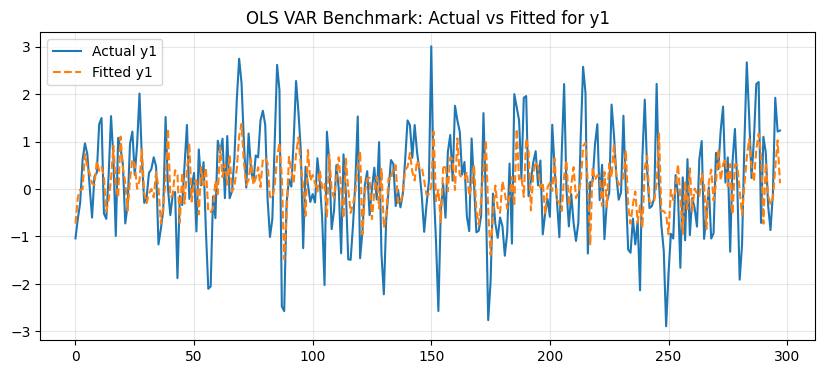

In [3]:
def fit_var_ols(Y, p, include_intercept=True):
    """
    Fit a VAR(p) by multivariate OLS:
        Y_target = X B + U
    """
    Y_target, X, feature_names = build_var_regression_matrices(
        Y=Y,
        p=p,
        include_intercept=include_intercept
    )

    XtX = X.T @ X
    XtY = X.T @ Y_target
    B_hat = np.linalg.solve(XtX, XtY)

    fitted_values = X @ B_hat
    residuals = Y_target - fitted_values

    T_eff, k_local = Y_target.shape
    Sigma_hat = (residuals.T @ residuals) / T_eff

    intercept_hat, A_hat_list = extract_var_coefficients(
        B_hat,
        k=k_local,
        p=p,
        include_intercept=include_intercept
    )

    return {
        "B_hat": B_hat,
        "residuals": residuals,
        "Sigma_hat": Sigma_hat,
        "Y_target": Y_target,
        "X": X,
        "feature_names": feature_names,
        "intercept": intercept_hat,
        "A_hat_list": A_hat_list,
        "fitted_values": fitted_values,
    }


# -----------------------------------------------------------------------------
# Fit OLS benchmark
# -----------------------------------------------------------------------------
var_ols_results = fit_var_ols(df.values, p=p, include_intercept=True)

B_hat = var_ols_results["B_hat"]
A_hat_list = var_ols_results["A_hat_list"]
Sigma_hat = var_ols_results["Sigma_hat"]
intercept_hat = var_ols_results["intercept"]

print("=" * 80)
print("OLS VAR BENCHMARK")
print("=" * 80)
print(f"Number of variables: {k}")
print(f"Lag order: {p}")
print(f"Effective sample size: {var_ols_results['Y_target'].shape[0]}")
print()

print("Estimated intercept:")
print(np.round(intercept_hat, 4))
print()

for lag, A_hat in enumerate(A_hat_list, start=1):
    print(f"Estimated A{lag}:")
    print(np.round(A_hat, 4))
    print()

print("Estimated Sigma_hat:")
print(np.round(Sigma_hat, 4))
print()

print("=" * 80)
print("COMPARISON TO TRUE DGP")
print("=" * 80)
for lag, (A_true, A_est) in enumerate(zip([A1, A2], A_hat_list), start=1):
    print(f"True A{lag}:")
    print(np.round(A_true, 4))
    print(f"Estimated A{lag}:")
    print(np.round(A_est, 4))
    print(f"Frobenius error for A{lag}: {np.linalg.norm(A_est - A_true):.4f}")
    print()

print("True Sigma:")
print(np.round(Sigma, 4))
print("Estimated Sigma_hat:")
print(np.round(Sigma_hat, 4))
print(f"Frobenius error for Sigma: {np.linalg.norm(Sigma_hat - Sigma):.4f}")
print()

stable_hat, max_modulus_hat, _ = is_var_stable(A_hat_list)
print("=" * 80)
print("STABILITY OF ESTIMATED OLS VAR")
print("=" * 80)
print(f"Estimated VAR stable: {stable_hat}")
print(f"Max eigenvalue modulus: {max_modulus_hat:.4f}")

# Quick fitted vs actual plot for y1
actual_df = pd.DataFrame(var_ols_results["Y_target"], columns=columns)
fitted_df = pd.DataFrame(
    var_ols_results["fitted_values"],
    columns=[f"{col}_fitted" for col in columns]
)

plt.figure(figsize=(10, 4))
plt.plot(actual_df.index, actual_df["y1"], label="Actual y1")
plt.plot(fitted_df.index, fitted_df["y1_fitted"], linestyle="--", label="Fitted y1")
plt.title("OLS VAR Benchmark: Actual vs Fitted for y1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Bayesian VAR with a Normal-Inverse-Wishart Prior

We now move from point estimation to Bayesian estimation.

The starting point is the multivariate regression form of the VAR:

$
Y = X B + U
$

with

$
U \sim MN(0, I_T, \Sigma)
$

so that, conditional on $\Sigma$, the likelihood is matrix normal.

We place a conjugate Normal-Inverse-Wishart prior on $(B,\Sigma)$:

$
\Sigma \sim IW(S_0,\nu_0)
$

$
B \mid \Sigma \sim MN(B_0, V_0, \Sigma)
$

where:

- $B_0$ is the prior mean matrix for the VAR coefficients
- $V_0$ is the prior row covariance
- $S_0$ is the scale matrix for $\Sigma$
- $\nu_0$ is the degrees of freedom

This prior is useful because:

- it is analytically tractable
- posterior updates have closed form
- posterior sampling is straightforward

Given the regression data $(X,Y)$, the posterior remains NIW with updated parameters:

$
V_n = (V_0^{-1} + X'X)^{-1}
$

$
B_n = V_n(V_0^{-1}B_0 + X'Y)
$

$
\nu_n = \nu_0 + T
$

$
S_n = S_0 + Y'Y + B_0'V_0^{-1}B_0 - B_n'V_n^{-1}B_n
$

The next cell will:

1. build a simple NIW prior
2. compute the posterior hyperparameters
3. print the posterior objects clearly before we start sampling

In [4]:
def make_niw_prior(m, k, prior_var_scale=10.0, sigma_scale=1.0):
    """
    Construct a simple NIW prior for VAR regression form Y = X B + U.

    Parameters
    ----------
    m : int
        Number of regressors per equation.
    k : int
        Number of endogenous variables.
    prior_var_scale : float
        Scale for V0 = prior_var_scale * I_m.
    sigma_scale : float
        Scale for S0 = sigma_scale * I_k.

    Returns
    -------
    prior : dict
        Contains B0, V0, S0, nu0.
    """
    B0 = np.zeros((m, k))
    V0 = prior_var_scale * np.eye(m)
    S0 = sigma_scale * np.eye(k)
    nu0 = k + 2  # minimally proper / weakly informative

    return {
        "B0": B0,
        "V0": V0,
        "S0": S0,
        "nu0": nu0
    }


def compute_niw_posterior(Y_target, X, B0, V0, S0, nu0):
    """
    Compute NIW posterior hyperparameters for multivariate regression.

    Model:
        Y | B, Sigma ~ MN(XB, I, Sigma)
        B | Sigma ~ MN(B0, V0, Sigma)
        Sigma ~ IW(S0, nu0)

    Returns
    -------
    posterior : dict
        Contains Bn, Vn, Sn, nun.
    """
    V0_inv = np.linalg.inv(V0)
    XtX = X.T @ X
    XtY = X.T @ Y_target

    Vn = np.linalg.inv(V0_inv + XtX)
    Bn = Vn @ (V0_inv @ B0 + XtY)

    T_eff = Y_target.shape[0]
    nun = nu0 + T_eff

    YtY = Y_target.T @ Y_target
    Sn = S0 + YtY + B0.T @ V0_inv @ B0 - Bn.T @ np.linalg.inv(Vn) @ Bn

    return {
        "Bn": Bn,
        "Vn": Vn,
        "Sn": Sn,
        "nun": nun
    }


# -----------------------------------------------------------------------------
# Build NIW prior and posterior
# -----------------------------------------------------------------------------
Y_target, X, feature_names = build_var_regression_matrices(
    df.values, p=p, include_intercept=True
)

T_eff, k_local = Y_target.shape
m = X.shape[1]

niw_prior = make_niw_prior(
    m=m,
    k=k_local,
    prior_var_scale=10.0,
    sigma_scale=1.0
)

niw_post = compute_niw_posterior(
    Y_target=Y_target,
    X=X,
    B0=niw_prior["B0"],
    V0=niw_prior["V0"],
    S0=niw_prior["S0"],
    nu0=niw_prior["nu0"]
)

print("=" * 80)
print("NIW PRIOR HYPERPARAMETERS")
print("=" * 80)
print(f"B0 shape: {niw_prior['B0'].shape}")
print(f"V0 shape: {niw_prior['V0'].shape}")
print(f"S0 shape: {niw_prior['S0'].shape}")
print(f"nu0: {niw_prior['nu0']}")
print()

print("Prior mean B0 (first 5 rows):")
print(np.round(niw_prior["B0"][:5], 4))
print()

print("=" * 80)
print("NIW POSTERIOR HYPERPARAMETERS")
print("=" * 80)
print(f"Bn shape: {niw_post['Bn'].shape}")
print(f"Vn shape: {niw_post['Vn'].shape}")
print(f"Sn shape: {niw_post['Sn'].shape}")
print(f"nun: {niw_post['nun']}")
print()

print("Posterior mean Bn (first 5 rows):")
print(np.round(niw_post["Bn"][:5], 4))
print()

print("Posterior scale matrix Sn:")
print(np.round(niw_post["Sn"], 4))
print()

# Quick check: Sn should be symmetric positive definite
Sn_sym = np.allclose(niw_post["Sn"], niw_post["Sn"].T)
Sn_eigs = np.linalg.eigvalsh(niw_post["Sn"])

print("=" * 80)
print("POSTERIOR SANITY CHECKS")
print("=" * 80)
print(f"Sn symmetric: {Sn_sym}")
print(f"Sn eigenvalues: {np.round(Sn_eigs, 6)}")
print(f"All Sn eigenvalues positive: {np.all(Sn_eigs > 0)}")

NIW PRIOR HYPERPARAMETERS
B0 shape: (7, 3)
V0 shape: (7, 7)
S0 shape: (3, 3)
nu0: 5

Prior mean B0 (first 5 rows):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

NIW POSTERIOR HYPERPARAMETERS
Bn shape: (7, 3)
Vn shape: (7, 7)
Sn shape: (3, 3)
nun: 303

Posterior mean Bn (first 5 rows):
[[ 0.1056 -0.0068  0.0034]
 [ 0.3898  0.0932  0.0215]
 [ 0.102   0.2964  0.101 ]
 [ 0.0727  0.0581  0.3026]
 [-0.2263  0.0195  0.0234]]

Posterior scale matrix Sn:
[[277.3918  93.6901  67.842 ]
 [ 93.6901 248.7407  85.9937]
 [ 67.842   85.9937 218.5612]]

POSTERIOR SANITY CHECKS
Sn symmetric: True
Sn eigenvalues: [145.12525  182.87569  416.692793]
All Sn eigenvalues positive: True


## Sampling from the NIW Posterior

With the posterior hyperparameters in hand, we can now generate posterior draws of:

- the innovation covariance matrix $\Sigma$
- the coefficient matrix $B$

Under the NIW posterior:

$
\Sigma \mid Y \sim IW(S_n, \nu_n)
$

and conditional on $\Sigma$,

$
B \mid \Sigma, Y \sim MN(B_n, V_n, \Sigma)
$

The sampling procedure is therefore:

1. Draw $\Sigma^{(s)}$ from the inverse-Wishart posterior
2. Draw $B^{(s)}$ from the matrix-normal posterior conditional on $\Sigma^{(s)}$
3. Extract:
   - intercept draws
   - lag-matrix draws $A_1^{(s)}, \dots, A_p^{(s)}$
4. Check how the posterior mean compares to the OLS benchmark and the true DGP

For the matrix-normal draw, we use the identity:

$
\mathrm{vec}(B) \sim \mathcal{N}\left(\mathrm{vec}(B_n), \Sigma \otimes V_n \right)
$

Equivalently, we can sample

$
B = B_n + L_V Z L_\Sigma^\top
$

where

- $L_V L_V^\top = V_n$
- $L_\Sigma L_\Sigma^\top = \Sigma$
- $Z$ has iid standard normal entries.

In [5]:
def sample_matrix_normal(M, U, V, rng):
    """
    Sample from a matrix normal distribution:
        X ~ MN(M, U, V)

    Meaning:
        vec(X) ~ N(vec(M), V \kron U)

    Parameters
    ----------
    M : np.ndarray
        Mean matrix of shape (r, c)
    U : np.ndarray
        Row covariance of shape (r, r)
    V : np.ndarray
        Column covariance of shape (c, c)
    rng : np.random.Generator
        Random number generator

    Returns
    -------
    X : np.ndarray
        Draw of shape (r, c)
    """
    r, c = M.shape
    L_U = np.linalg.cholesky(U)
    L_V = np.linalg.cholesky(V)
    Z = rng.standard_normal((r, c))
    return M + L_U @ Z @ L_V.T


def sample_niw_posterior_draws(niw_post, n_draws=2000, seed=123):
    """
    Sample posterior draws from the NIW posterior.

    Returns
    -------
    draws : dict
        Contains B_draws and Sigma_draws
    """
    local_rng = np.random.default_rng(seed)

    Bn = niw_post["Bn"]
    Vn = niw_post["Vn"]
    Sn = niw_post["Sn"]
    nun = niw_post["nun"]

    m, k_local = Bn.shape

    B_draws = np.zeros((n_draws, m, k_local))
    Sigma_draws = np.zeros((n_draws, k_local, k_local))

    for s in range(n_draws):
        Sigma_s = invwishart.rvs(df=nun, scale=Sn, random_state=local_rng)
        B_s = sample_matrix_normal(M=Bn, U=Vn, V=Sigma_s, rng=local_rng)

        B_draws[s] = B_s
        Sigma_draws[s] = Sigma_s

    return {
        "B_draws": B_draws,
        "Sigma_draws": Sigma_draws
    }


def summarize_niw_draws(B_draws, Sigma_draws, p, include_intercept=True):
    """
    Convert posterior draws into summaries for intercepts, A matrices, and Sigma.
    """
    n_draws, m, k_local = B_draws.shape

    intercept_draws = []
    A_draws_by_lag = [[] for _ in range(p)]

    for s in range(n_draws):
        intercept_s, A_list_s = extract_var_coefficients(
            B_draws[s],
            k=k_local,
            p=p,
            include_intercept=include_intercept
        )

        intercept_draws.append(intercept_s)
        for lag in range(p):
            A_draws_by_lag[lag].append(A_list_s[lag])

    intercept_draws = np.array(intercept_draws)
    A_draws_by_lag = [np.array(x) for x in A_draws_by_lag]

    return {
        "intercept_draws": intercept_draws,
        "A_draws_by_lag": A_draws_by_lag,
        "Sigma_draws": Sigma_draws
    }


# -----------------------------------------------------------------------------
# Draw from the NIW posterior
# -----------------------------------------------------------------------------
n_draws = 2000

niw_draws = sample_niw_posterior_draws(
    niw_post=niw_post,
    n_draws=n_draws,
    seed=GLOBAL_SEED
)

niw_summaries = summarize_niw_draws(
    B_draws=niw_draws["B_draws"],
    Sigma_draws=niw_draws["Sigma_draws"],
    p=p,
    include_intercept=True
)

print("=" * 80)
print("NIW POSTERIOR SAMPLING COMPLETE")
print("=" * 80)
print(f"Number of posterior draws: {n_draws}")
print(f"B_draws shape: {niw_draws['B_draws'].shape}")
print(f"Sigma_draws shape: {niw_draws['Sigma_draws'].shape}")
print()

# Posterior means
B_post_mean = niw_draws["B_draws"].mean(axis=0)
Sigma_post_mean = niw_draws["Sigma_draws"].mean(axis=0)

intercept_post_mean, A_post_mean_list = extract_var_coefficients(
    B_post_mean,
    k=k,
    p=p,
    include_intercept=True
)

print("=" * 80)
print("POSTERIOR MEAN COMPARISON")
print("=" * 80)
print("Posterior mean intercept:")
print(np.round(intercept_post_mean, 4))
print("OLS intercept:")
print(np.round(intercept_hat, 4))
print()

for lag in range(p):
    print(f"Posterior mean A{lag+1}:")
    print(np.round(A_post_mean_list[lag], 4))
    print(f"OLS A{lag+1}:")
    print(np.round(A_hat_list[lag], 4))
    print(f"True A{lag+1}:")
    print(np.round([A1, A2][lag], 4))
    print()

print("Posterior mean Sigma:")
print(np.round(Sigma_post_mean, 4))
print("OLS Sigma_hat:")
print(np.round(Sigma_hat, 4))
print("True Sigma:")
print(np.round(Sigma, 4))
print()

# Stability fraction across posterior draws
stable_count = 0
max_moduli = []

for s in range(n_draws):
    _, A_list_s = extract_var_coefficients(
        niw_draws["B_draws"][s],
        k=k,
        p=p,
        include_intercept=True
    )
    stable_s, max_mod_s, _ = is_var_stable(A_list_s)
    stable_count += int(stable_s)
    max_moduli.append(max_mod_s)

stable_fraction = stable_count / n_draws

print("=" * 80)
print("POSTERIOR STABILITY SUMMARY")
print("=" * 80)
print(f"Fraction of posterior draws that are stable: {stable_fraction:.4f}")
print(f"Average max eigenvalue modulus across draws: {np.mean(max_moduli):.4f}")
print(f"Min / Max max-modulus across draws: {np.min(max_moduli):.4f} / {np.max(max_moduli):.4f}")

NIW POSTERIOR SAMPLING COMPLETE
Number of posterior draws: 2000
B_draws shape: (2000, 7, 3)
Sigma_draws shape: (2000, 3, 3)

POSTERIOR MEAN COMPARISON
Posterior mean intercept:
[ 0.1064 -0.0048  0.0028]
OLS intercept:
[ 0.1056 -0.0068  0.0034]

Posterior mean A1:
[[0.3878 0.1032 0.0719]
 [0.0919 0.2943 0.0568]
 [0.0202 0.1024 0.302 ]]
OLS A1:
[[0.39   0.102  0.0727]
 [0.0932 0.2965 0.0581]
 [0.0215 0.101  0.3027]]
True A1:
[[0.5  0.1  0.  ]
 [0.05 0.4  0.1 ]
 [0.   0.1  0.35]]

Posterior mean A2:
[[-0.2236 -0.0352  0.1457]
 [ 0.0186 -0.0645 -0.0428]
 [ 0.0236 -0.0189 -0.0592]]
OLS A2:
[[-0.2265 -0.0332  0.1451]
 [ 0.0195 -0.0657 -0.0462]
 [ 0.0234 -0.0173 -0.0618]]
True A2:
[[-0.2   0.    0.05]
 [ 0.   -0.15  0.  ]
 [ 0.05  0.   -0.1 ]]

Posterior mean Sigma:
[[0.9297 0.3125 0.2251]
 [0.3125 0.8301 0.2854]
 [0.2251 0.2854 0.7296]]
OLS Sigma_hat:
[[0.9274 0.3144 0.2276]
 [0.3144 0.8313 0.2886]
 [0.2276 0.2886 0.73  ]]
True Sigma:
[[1.   0.3  0.2 ]
 [0.3  0.8  0.25]
 [0.2  0.25 0.6 ]]

P

## Posterior Diagnostics: Trace Plots and Effective Sample Size

Now that we have posterior draws from the NIW BVAR, we want to verify that the sampled posterior behaves sensibly.

Even though the NIW posterior is sampled directly rather than via MCMC, trace plots and ESS-style summaries are still useful for checking:

- whether the draws look stable and well-mixed
- whether there are numerical pathologies
- whether the posterior mass is concentrated in reasonable regions

We will inspect a few representative quantities:

1. intercept for equation 1
2. own-lag coefficient in $A_1$
3. cross-lag coefficient in $A_1$
4. variance element $\Sigma_{11}$
5. covariance element $\Sigma_{12}$

If ArviZ is available, we will also compute effective sample size for these quantities.

POSTERIOR DIAGNOSTIC SERIES
intercept_y1    | mean =  0.1064 | std =  0.0564 | min = -0.0881 | max =  0.3219
A1_y1_on_y1     | mean =  0.3878 | std =  0.0607 | min =  0.1816 | max =  0.6327
A1_y2_on_y1     | mean =  0.1032 | std =  0.0668 | min = -0.0942 | max =  0.3613
Sigma_11        | mean =  0.9297 | std =  0.0767 | min =  0.7391 | max =  1.2799
Sigma_12        | mean =  0.3125 | std =  0.0538 | min =  0.1431 | max =  0.5422


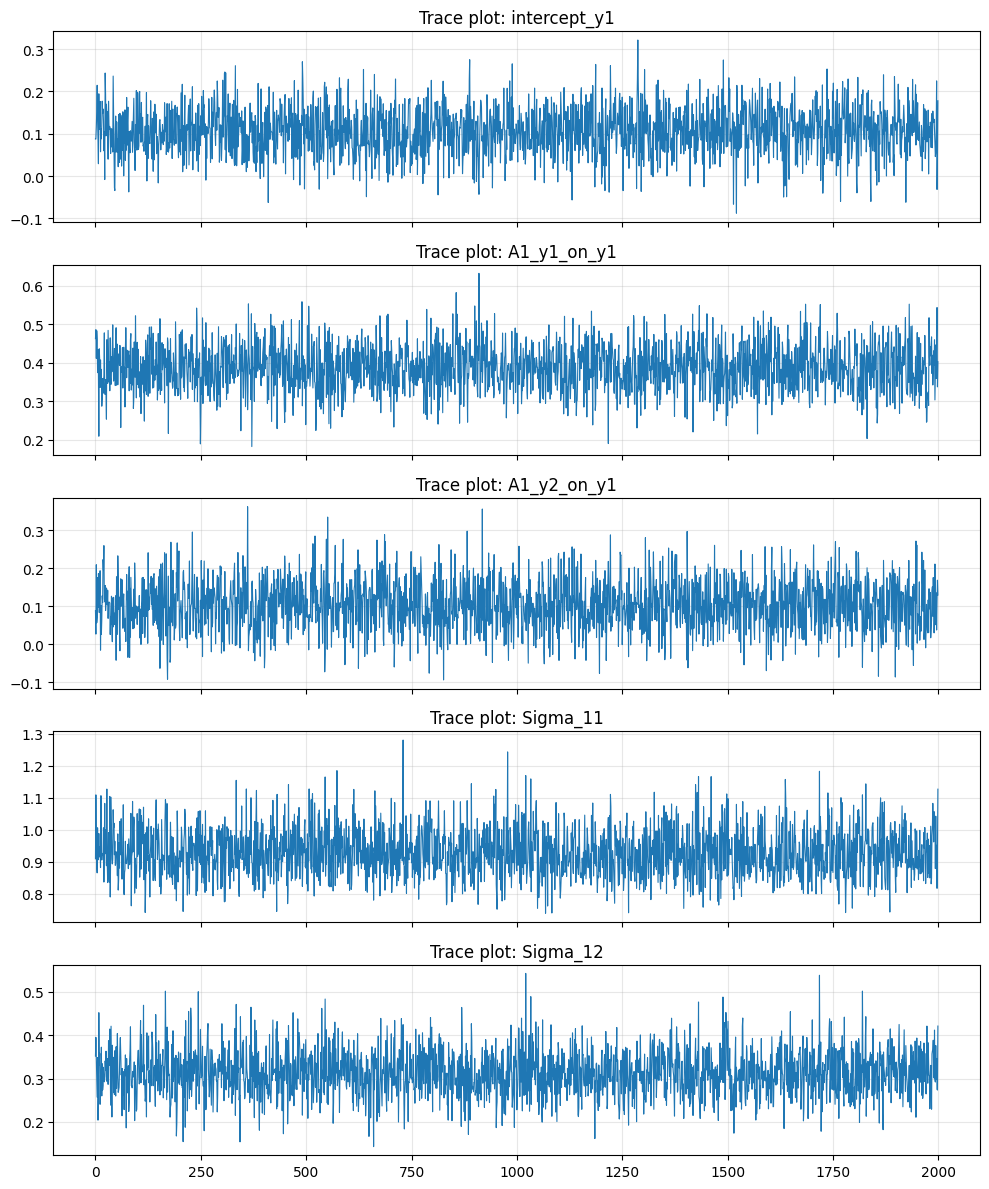

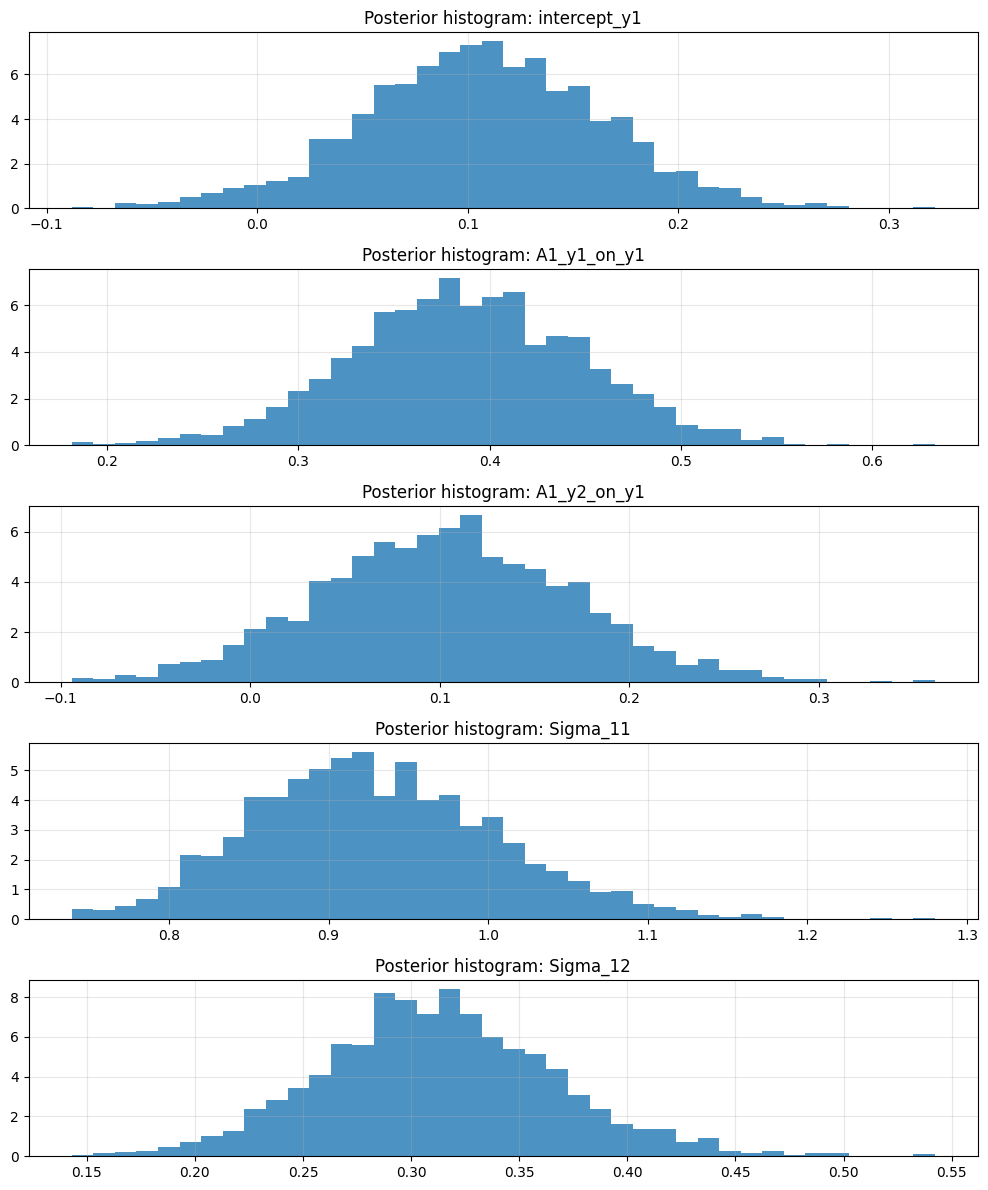

EFFECTIVE SAMPLE SIZE


,parameter,ESS,draws,ESS_fraction,method
0,intercept_y1,1995.575189,2000,0.997788,arviz
1,A1_y1_on_y1,1983.967809,2000,0.991984,arviz
2,A1_y2_on_y1,1998.792864,2000,0.999396,arviz
3,Sigma_11,1936.770794,2000,0.968385,arviz
4,Sigma_12,2050.082301,2000,1.025041,arviz


In [6]:
# -----------------------------------------------------------------------------
# Select representative posterior series for diagnostics
# -----------------------------------------------------------------------------
# B has rows: const, y1_lag1, y2_lag1, y3_lag1, y1_lag2, y2_lag2, y3_lag2
# B columns correspond to equations y1, y2, y3

diag_series = {
    "intercept_y1": niw_draws["B_draws"][:, 0, 0],
    "A1_y1_on_y1": niw_draws["B_draws"][:, 1, 0],   # row y1_lag1, col eq1
    "A1_y2_on_y1": niw_draws["B_draws"][:, 2, 0],   # row y2_lag1, col eq1
    "Sigma_11": niw_draws["Sigma_draws"][:, 0, 0],
    "Sigma_12": niw_draws["Sigma_draws"][:, 0, 1],
}

print("=" * 80)
print("POSTERIOR DIAGNOSTIC SERIES")
print("=" * 80)
for name, values in diag_series.items():
    print(
        f"{name:15s} | mean = {values.mean(): .4f} | std = {values.std(ddof=1): .4f} "
        f"| min = {values.min(): .4f} | max = {values.max(): .4f}"
    )

# -----------------------------------------------------------------------------
# Trace plots
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(len(diag_series), 1, figsize=(10, 12), sharex=True)

for ax, (name, values) in zip(axes, diag_series.items()):
    ax.plot(values, linewidth=0.8)
    ax.set_title(f"Trace plot: {name}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Histograms
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(len(diag_series), 1, figsize=(10, 12))

for ax, (name, values) in zip(axes, diag_series.items()):
    ax.hist(values, bins=40, density=True, alpha=0.8)
    ax.set_title(f"Posterior histogram: {name}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Effective sample size
# -----------------------------------------------------------------------------
def naive_ess(x, max_lag=200):
    """
    Simple autocorrelation-based ESS approximation for a 1D series.
    Useful fallback if ArviZ is unavailable.
    """
    x = np.asarray(x)
    n = len(x)
    x_centered = x - x.mean()
    var = np.dot(x_centered, x_centered) / n

    if var <= 0:
        return float(n)

    autocorrs = []
    for lag in range(1, min(max_lag, n - 1) + 1):
        c = np.dot(x_centered[:-lag], x_centered[lag:]) / n
        rho = c / var
        autocorrs.append(rho)

        # initial positive sequence truncation
        if rho < 0:
            break

    tau = 1.0 + 2.0 * np.sum(autocorrs)
    ess = n / tau if tau > 0 else float(n)
    return max(1.0, min(float(n), ess))


print("=" * 80)
print("EFFECTIVE SAMPLE SIZE")
print("=" * 80)

ess_rows = []
for name, values in diag_series.items():
    if ARVIZ_AVAILABLE:
        ess_val = float(az.ess(np.asarray(values)))
        method_used = "arviz"
    else:
        ess_val = naive_ess(values)
        method_used = "naive_acf"

    ess_rows.append({
        "parameter": name,
        "ESS": ess_val,
        "draws": len(values),
        "ESS_fraction": ess_val / len(values),
        "method": method_used
    })

ess_df = pd.DataFrame(ess_rows)
display(ess_df)

## Posterior Predictive Forecasting for the NIW BVAR

The main advantage of the Bayesian VAR is that forecasting is now based on the full posterior distribution rather than a single point estimate.

For each posterior draw $s$:

1. extract $(B^{(s)}, \Sigma^{(s)})$
2. recover the implied VAR coefficient matrices
3. generate a forecast path conditional on that draw
4. aggregate forecasts across draws

This produces:

- posterior predictive means
- posterior predictive intervals
- a distribution over future paths

For now we compute **point forecasts from each posterior draw** and summarize across draws. Later we can add explicit shock simulation if needed.

NIW BVAR POSTERIOR PREDICTIVE FORECASTS
Forecast draws shape: (2000, 10, 3)
Forecast horizon: 10

Posterior predictive mean forecasts:


,y1_mean,y2_mean,y3_mean
1,0.364052,0.387945,0.092328
2,-0.043287,0.122712,0.101580
3,0.030156,0.011589,0.040167
4,0.145164,-0.006302,0.006619
5,0.162723,0.007538,0.005767
6,0.139379,0.016787,0.012459
7,0.126906,0.016448,0.014721
8,0.128429,0.013789,0.013638
9,0.131978,0.012810,0.012601
10,0.132669,0.013074,0.012496


OLS point forecast from same forecast origin:


,y1_ols,y2_ols,y3_ols
1,0.361628,0.390710,0.093630
2,-0.048046,0.120801,0.105099
3,0.025594,0.007668,0.042330
4,0.141599,-0.013460,0.007836
5,0.160141,0.000854,0.005313
6,0.138073,0.011926,0.011610
7,0.126015,0.013056,0.014503
8,0.127182,0.010986,0.014136
9,0.130513,0.010017,0.013360
10,0.131407,0.010171,0.013185


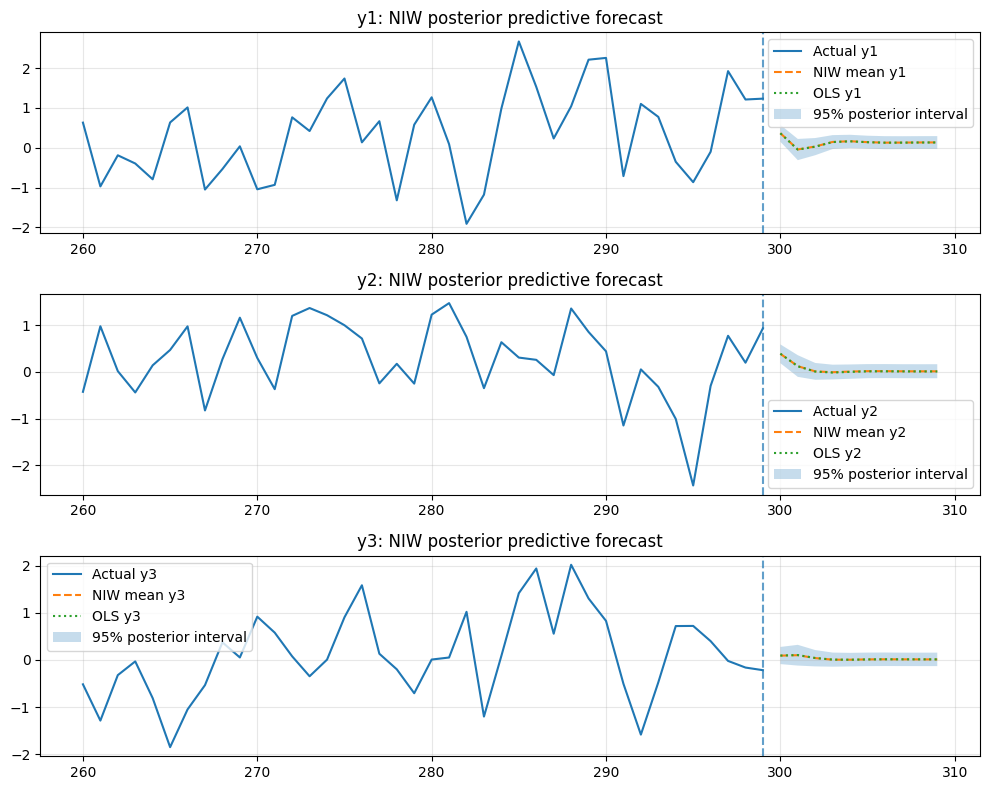

In [7]:
def bvar_posterior_predictive_draws(B_draws, Sigma_draws, y_history, p, h, include_intercept=True):
    """
    Compute h-step forecast paths for each posterior draw of the NIW BVAR.

    Parameters
    ----------
    B_draws : np.ndarray
        Posterior draws of B, shape (n_draws, m, k)
    Sigma_draws : np.ndarray
        Posterior draws of Sigma, shape (n_draws, k, k)
        Included for API consistency; not used yet because forecasts are conditional means.
    y_history : np.ndarray
        Most recent observed history, shape (p, k), oldest -> newest
    p : int
        Lag order
    h : int
        Forecast horizon
    include_intercept : bool
        Whether B includes an intercept row

    Returns
    -------
    forecast_draws : np.ndarray
        Array of shape (n_draws, h, k)
    """
    n_draws, _, k_local = B_draws.shape
    forecast_draws = np.zeros((n_draws, h, k_local))

    for s in range(n_draws):
        intercept_s, A_list_s = extract_var_coefficients(
            B_draws[s],
            k=k_local,
            p=p,
            include_intercept=include_intercept
        )

        forecast_draws[s] = var_forecast(
            A_list=A_list_s,
            intercept=intercept_s,
            y_history=y_history,
            h=h
        )

    return forecast_draws


def summarize_forecast_draws(forecast_draws, alpha=0.05):
    """
    Summarize posterior predictive forecast draws by mean and central interval.
    """
    mean_fcst = forecast_draws.mean(axis=0)
    lower_fcst = np.quantile(forecast_draws, alpha / 2, axis=0)
    upper_fcst = np.quantile(forecast_draws, 1 - alpha / 2, axis=0)

    return {
        "mean": mean_fcst,
        "lower": lower_fcst,
        "upper": upper_fcst
    }


# -----------------------------------------------------------------------------
# Posterior predictive example from the end of the sample
# -----------------------------------------------------------------------------
h_bvar = 10
y_history = df.values[-p:, :]

niw_forecast_draws = bvar_posterior_predictive_draws(
    B_draws=niw_draws["B_draws"],
    Sigma_draws=niw_draws["Sigma_draws"],
    y_history=y_history,
    p=p,
    h=h_bvar,
    include_intercept=True
)

niw_forecast_summary = summarize_forecast_draws(
    niw_forecast_draws,
    alpha=0.05
)

print("=" * 80)
print("NIW BVAR POSTERIOR PREDICTIVE FORECASTS")
print("=" * 80)
print(f"Forecast draws shape: {niw_forecast_draws.shape}")
print(f"Forecast horizon: {h_bvar}")
print()

forecast_mean_df = pd.DataFrame(
    niw_forecast_summary["mean"],
    columns=[f"{col}_mean" for col in columns],
    index=np.arange(1, h_bvar + 1)
)

forecast_lower_df = pd.DataFrame(
    niw_forecast_summary["lower"],
    columns=[f"{col}_lower" for col in columns],
    index=np.arange(1, h_bvar + 1)
)

forecast_upper_df = pd.DataFrame(
    niw_forecast_summary["upper"],
    columns=[f"{col}_upper" for col in columns],
    index=np.arange(1, h_bvar + 1)
)

print("Posterior predictive mean forecasts:")
display(forecast_mean_df)

# Compare to OLS point forecast from same history
ols_forecast_path = var_forecast(
    A_list=A_hat_list,
    intercept=intercept_hat,
    y_history=y_history,
    h=h_bvar
)

ols_forecast_df = pd.DataFrame(
    ols_forecast_path,
    columns=[f"{col}_ols" for col in columns],
    index=np.arange(1, h_bvar + 1)
)

print("OLS point forecast from same forecast origin:")
display(ols_forecast_df)

# Plot recent history + NIW posterior predictive intervals + OLS mean path
plot_window = 40
recent_actual = df.iloc[-plot_window:].copy()
future_index = np.arange(recent_actual.index[-1] + 1, recent_actual.index[-1] + h_bvar + 1)

fig, axes = plt.subplots(k, 1, figsize=(10, 8), sharex=False)

for j, col in enumerate(columns):
    axes[j].plot(
        recent_actual.index,
        recent_actual[col],
        label=f"Actual {col}"
    )
    axes[j].plot(
        future_index,
        niw_forecast_summary["mean"][:, j],
        linestyle="--",
        label=f"NIW mean {col}"
    )
    axes[j].plot(
        future_index,
        ols_forecast_path[:, j],
        linestyle=":",
        label=f"OLS {col}"
    )
    axes[j].fill_between(
        future_index,
        niw_forecast_summary["lower"][:, j],
        niw_forecast_summary["upper"][:, j],
        alpha=0.25,
        label="95% posterior interval"
    )
    axes[j].axvline(recent_actual.index[-1], linestyle="--", alpha=0.7)
    axes[j].set_title(f"{col}: NIW posterior predictive forecast")
    axes[j].grid(alpha=0.3)
    axes[j].legend()

plt.tight_layout()
plt.show()

## Rolling Forecast Evaluation for the NIW BVAR

To evaluate the Bayesian VAR in a realistic forecasting setting, we perform a **rolling pseudo out-of-sample forecast experiment**, similar to the one used in the VAR notebook.

The procedure is:

1. Select an initial training window.
2. Fit the NIW BVAR on that window.
3. Draw posterior samples of $(B,\Sigma)$.
4. Generate a posterior predictive distribution for the next observation.
5. Record:
   - posterior predictive mean
   - predictive interval
   - realized value.
6. Move the training window forward by one period and repeat.

This produces a sequence of forecasts that can be used to compute:

- RMSE
- MAE
- predictive interval coverage
- log predictive density

For computational simplicity in the notebook, we will use a **moderate number of posterior draws** at each forecast origin.

ROLLING NIW BVAR FORECAST RESULTS
Training window: 220
Forecast horizon: 1
Number of forecasts: 80

First few forecast records:


,forecast_origin,target_time,y1_forecast,y1_actual,y1_error,y1_lower,y1_upper,y1_covered,y2_forecast,y2_actual,y2_error,y2_lower,y2_upper,y2_covered,y3_forecast,y3_actual,y3_error,y3_lower,y3_upper,y3_covered
0,219,220,0.561413,0.152819,0.408594,0.091854,1.030870,1,0.745734,0.327796,0.417938,0.332985,1.177590,0,0.700056,-0.858689,1.558745,0.303762,1.100313,0
1,220,221,0.190318,0.930831,-0.740512,-0.131383,0.533819,0,-0.202555,0.894734,-1.097289,-0.492851,0.104532,0,-0.271674,-1.400108,1.128434,-0.537045,0.019449,0
2,221,222,0.367719,1.364409,-0.996691,0.030107,0.685356,0,0.296258,0.659352,-0.363094,-0.036262,0.634007,0,-0.231857,0.118330,-0.350187,-0.549226,0.098733,0
3,222,223,0.467918,-0.234954,0.702872,0.134282,0.846674,0,0.524248,-0.323173,0.847421,0.189819,0.877541,0,0.249123,-0.330053,0.579176,-0.051243,0.591585,0
4,223,224,-0.340403,0.510563,-0.850966,-0.588883,-0.124650,0,-0.037780,0.315203,-0.352983,-0.258961,0.172667,0,-0.094349,0.061603,-0.155952,-0.324435,0.094499,1


Forecast performance metrics:


,variable,RMSE,MAE,coverage
0,y1,1.025823,0.851184,0.2375
1,y2,0.929145,0.745326,0.2250
2,y3,0.842521,0.679395,0.2000


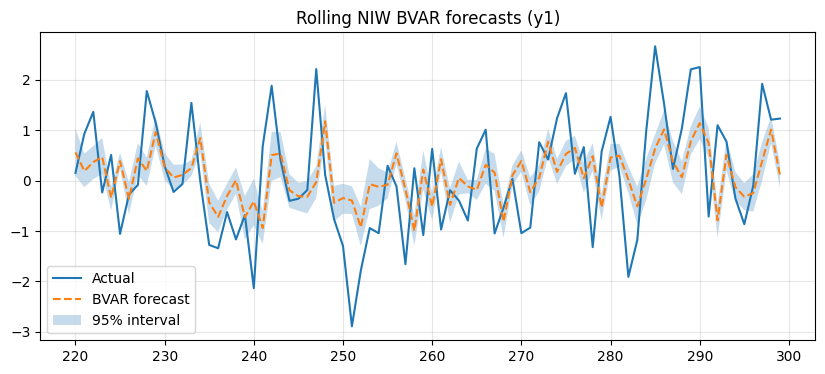

In [8]:
def rolling_bvar_forecast(
    Y,
    p,
    train_size,
    horizon,
    n_draws=500,
    include_intercept=True
):
    """
    Rolling forecast experiment for NIW BVAR.
    """

    Y = np.asarray(Y)
    T, k_local = Y.shape

    records = []

    for train_end in range(train_size, T - horizon + 1):

        Y_train = Y[:train_end]

        # build regression matrices
        Y_target_train, X_train, _ = build_var_regression_matrices(
            Y_train,
            p=p,
            include_intercept=include_intercept
        )

        # prior
        m = X_train.shape[1]
        prior = make_niw_prior(m, k_local)

        # posterior
        post = compute_niw_posterior(
            Y_target_train,
            X_train,
            prior["B0"],
            prior["V0"],
            prior["S0"],
            prior["nu0"]
        )

        # posterior draws
        draws = sample_niw_posterior_draws(
            post,
            n_draws=n_draws,
            seed=GLOBAL_SEED
        )

        # history for forecast
        y_history = Y_train[-p:]

        forecast_draws = bvar_posterior_predictive_draws(
            B_draws=draws["B_draws"],
            Sigma_draws=draws["Sigma_draws"],
            y_history=y_history,
            p=p,
            h=horizon
        )

        mean_fcst = forecast_draws.mean(axis=0)[-1]
        lower_fcst = np.quantile(forecast_draws, 0.025, axis=0)[-1]
        upper_fcst = np.quantile(forecast_draws, 0.975, axis=0)[-1]

        actual = Y[train_end + horizon - 1]

        row = {
            "forecast_origin": train_end - 1,
            "target_time": train_end + horizon - 1
        }

        for j in range(k_local):

            row[f"y{j+1}_forecast"] = mean_fcst[j]
            row[f"y{j+1}_actual"] = actual[j]
            row[f"y{j+1}_error"] = mean_fcst[j] - actual[j]

            row[f"y{j+1}_lower"] = lower_fcst[j]
            row[f"y{j+1}_upper"] = upper_fcst[j]

            row[f"y{j+1}_covered"] = int(
                lower_fcst[j] <= actual[j] <= upper_fcst[j]
            )

        records.append(row)

    return pd.DataFrame(records)


def compute_bvar_metrics(results_df, k_local):

    rows = []

    for j in range(1, k_local + 1):

        errors = results_df[f"y{j}_error"]

        rmse = np.sqrt(np.mean(errors**2))
        mae = np.mean(np.abs(errors))
        coverage = results_df[f"y{j}_covered"].mean()

        rows.append({
            "variable": f"y{j}",
            "RMSE": rmse,
            "MAE": mae,
            "coverage": coverage
        })

    return pd.DataFrame(rows)


# -----------------------------------------------------------------------------
# Run rolling BVAR forecast experiment
# -----------------------------------------------------------------------------
train_size = 220
horizon = 1

rolling_bvar_results = rolling_bvar_forecast(
    df.values,
    p=p,
    train_size=train_size,
    horizon=horizon,
    n_draws=500
)

bvar_metrics = compute_bvar_metrics(
    rolling_bvar_results,
    k
)

print("=" * 80)
print("ROLLING NIW BVAR FORECAST RESULTS")
print("=" * 80)
print(f"Training window: {train_size}")
print(f"Forecast horizon: {horizon}")
print(f"Number of forecasts: {len(rolling_bvar_results)}")
print()

print("First few forecast records:")
display(rolling_bvar_results.head())

print("Forecast performance metrics:")
display(bvar_metrics)

# Plot forecasts for first variable
plt.figure(figsize=(10,4))

plt.plot(
    rolling_bvar_results["target_time"],
    rolling_bvar_results["y1_actual"],
    label="Actual"
)

plt.plot(
    rolling_bvar_results["target_time"],
    rolling_bvar_results["y1_forecast"],
    linestyle="--",
    label="BVAR forecast"
)

plt.fill_between(
    rolling_bvar_results["target_time"],
    rolling_bvar_results["y1_lower"],
    rolling_bvar_results["y1_upper"],
    alpha=0.25,
    label="95% interval"
)

plt.legend()
plt.title("Rolling NIW BVAR forecasts (y1)")
plt.grid(alpha=0.3)
plt.show()

## Log Predictive Density for the NIW BVAR

Beyond point forecast accuracy and interval coverage, a useful way to evaluate probabilistic forecasts is the **log predictive density**.

For each forecast origin $t$, the BVAR produces a posterior predictive distribution:

$
p(y_{t+1} \mid \mathcal{F}_t)
$

Since we generate posterior predictive draws, we can approximate this density by a Gaussian using the sample mean and covariance of the forecast draws.

For each forecast origin:

1. compute posterior predictive mean
2. compute predictive covariance from forecast draws
3. evaluate the log-density of the realized value

$
\log p(y_{t+1} \mid \mathcal{F}_t)
$

Higher log predictive density indicates better calibrated probabilistic forecasts.

LOG PREDICTIVE DENSITY
Average log predictive density: -72.1852767198914
Median log predictive density: -47.77935894675774
Std of log predictive density: 78.93862683360054



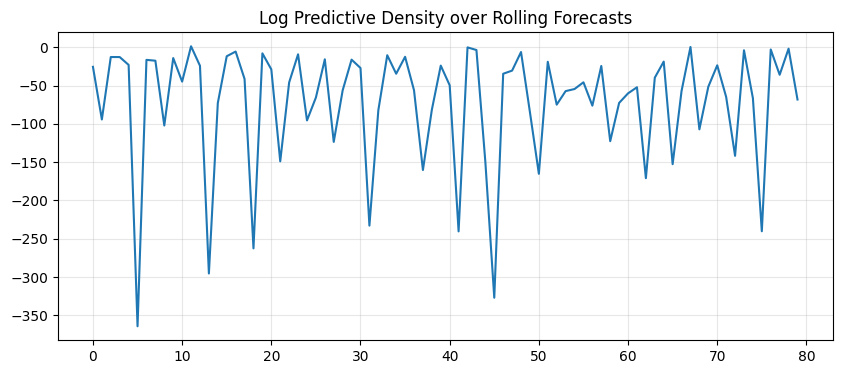

In [9]:
from scipy.stats import multivariate_normal

def compute_bvar_log_predictive_density(results_df, forecast_draws_all):
    """
    Compute log predictive density for each forecast origin using
    Gaussian approximation to posterior predictive distribution.
    """

    log_scores = []

    n_forecasts = len(results_df)

    for i in range(n_forecasts):

        draws = forecast_draws_all[i]

        mean_pred = draws.mean(axis=0)
        cov_pred = np.cov(draws.T)

        actual = np.array([
            results_df.iloc[i]["y1_actual"],
            results_df.iloc[i]["y2_actual"],
            results_df.iloc[i]["y3_actual"]
        ])

        logp = multivariate_normal.logpdf(
            actual,
            mean=mean_pred,
            cov=cov_pred
        )

        log_scores.append(logp)

    return np.array(log_scores)


# -----------------------------------------------------------------------------
# Re-run rolling forecast to collect predictive draws
# -----------------------------------------------------------------------------
def rolling_bvar_forecast_with_draws(
    Y,
    p,
    train_size,
    horizon,
    n_draws=500
):

    Y = np.asarray(Y)
    T, k_local = Y.shape

    records = []
    all_forecast_draws = []

    for train_end in range(train_size, T - horizon + 1):

        Y_train = Y[:train_end]

        Y_target_train, X_train, _ = build_var_regression_matrices(
            Y_train,
            p=p,
            include_intercept=True
        )

        m = X_train.shape[1]

        prior = make_niw_prior(m, k_local)

        post = compute_niw_posterior(
            Y_target_train,
            X_train,
            prior["B0"],
            prior["V0"],
            prior["S0"],
            prior["nu0"]
        )

        draws = sample_niw_posterior_draws(
            post,
            n_draws=n_draws,
            seed=GLOBAL_SEED
        )

        y_history = Y_train[-p:]

        forecast_draws = bvar_posterior_predictive_draws(
            draws["B_draws"],
            draws["Sigma_draws"],
            y_history,
            p,
            h=horizon
        )

        forecast_draws_last = forecast_draws[:, -1, :]
        all_forecast_draws.append(forecast_draws_last)

        mean_fcst = forecast_draws_last.mean(axis=0)
        lower_fcst = np.quantile(forecast_draws_last, 0.025, axis=0)
        upper_fcst = np.quantile(forecast_draws_last, 0.975, axis=0)

        actual = Y[train_end + horizon - 1]

        row = {
            "forecast_origin": train_end - 1,
            "target_time": train_end + horizon - 1
        }

        for j in range(k_local):

            row[f"y{j+1}_forecast"] = mean_fcst[j]
            row[f"y{j+1}_actual"] = actual[j]
            row[f"y{j+1}_error"] = mean_fcst[j] - actual[j]

            row[f"y{j+1}_lower"] = lower_fcst[j]
            row[f"y{j+1}_upper"] = upper_fcst[j]

            row[f"y{j+1}_covered"] = int(
                lower_fcst[j] <= actual[j] <= upper_fcst[j]
            )

        records.append(row)

    return pd.DataFrame(records), all_forecast_draws


# -----------------------------------------------------------------------------
# Run rolling BVAR forecast with predictive draws
# -----------------------------------------------------------------------------
rolling_bvar_results, forecast_draws_all = rolling_bvar_forecast_with_draws(
    df.values,
    p=p,
    train_size=train_size,
    horizon=1,
    n_draws=500
)

log_scores = compute_bvar_log_predictive_density(
    rolling_bvar_results,
    forecast_draws_all
)

print("=" * 80)
print("LOG PREDICTIVE DENSITY")
print("=" * 80)

print("Average log predictive density:", np.mean(log_scores))
print("Median log predictive density:", np.median(log_scores))
print("Std of log predictive density:", np.std(log_scores))
print()

plt.figure(figsize=(10,4))
plt.plot(log_scores)
plt.title("Log Predictive Density over Rolling Forecasts")
plt.grid(alpha=0.3)
plt.show()

## Minnesota Prior Setup

The next Bayesian specification is the **Minnesota prior**, which is widely used in macroeconometrics because it introduces structured shrinkage directly on the VAR coefficients.

The main idea is:

- own lags are allowed to matter more
- cross-variable lags are shrunk more strongly
- longer lags are shrunk more strongly
- intercepts are usually treated separately with a diffuse prior

A common prior mean is:

- first own lag near 1 for random-walk type behavior, or
- all coefficients centered at 0 for stationary simulated data

Since our simulated VAR is stationary around zero, we will use a **zero-centered Minnesota prior** for simplicity.

For coefficient $b_{i,j,\ell}$, corresponding to variable $j$ at lag $\ell$ in equation $i$, the prior variance is typically of the form:

$$
\mathrm{Var}(b_{i,j,\ell})
=
\begin{cases}
\displaystyle \frac{\lambda_1^2}{\ell^{2\lambda_3}}, & i=j \\
\displaystyle \frac{\lambda_1^2 \lambda_2^2}{\ell^{2\lambda_3}} \frac{\sigma_i^2}{\sigma_j^2}, & i \neq j
\end{cases}
$$

where:

- $\lambda_1$ controls overall tightness
- $\lambda_2$ controls shrinkage on cross lags
- $\lambda_3$ controls lag decay
- $\sigma_i^2, \sigma_j^2$ are scale adjustments, often based on residual variances

In this notebook, we start with a simple implementation:

1. estimate residual variances from the OLS VAR
2. construct the Minnesota prior mean and diagonal prior variance
3. compute the conditional Gaussian posterior for $B$ given a plug-in covariance estimate $\hat{\Sigma}$

This keeps the implementation transparent before moving to more elaborate Bayesian variants.

In [10]:
def build_minnesota_prior(
    k,
    p,
    sigma_diag,
    include_intercept=True,
    lambda1=0.2,
    lambda2=0.5,
    lambda3=1.0,
    intercept_var=1e4,
    stationary_zero_mean=True,
    sigma_floor=1e-6,
    var_floor=1e-10,
    var_cap=1e6
):
    """
    Build a numerically safe Minnesota prior for the VAR regression form
        Y = X B + U

    Parameters
    ----------
    k : int
        Number of endogenous variables.
    p : int
        Number of lags.
    sigma_diag : np.ndarray
        Residual variances for each equation, shape (k,).
    include_intercept : bool
        Whether an intercept is included.
    lambda1 : float
        Overall tightness.
    lambda2 : float
        Cross-lag shrinkage factor.
    lambda3 : float
        Lag decay factor.
    intercept_var : float
        Prior variance for intercept terms.
    stationary_zero_mean : bool
        If True, center all lag coefficients at 0.
        If False, center first own lag at 1 and others at 0.
    sigma_floor : float
        Minimum allowed residual variance for scaling.
    var_floor : float
        Minimum allowed prior variance entry.
    var_cap : float
        Maximum allowed prior variance entry.

    Returns
    -------
    prior : dict
        Contains:
        - B0 : prior mean matrix, shape (m, k)
        - V0_list : list of diagonal prior covariance matrices, one per equation
        - sigma_diag_safe : clipped residual variances used in scaling
    """
    sigma_diag = np.asarray(sigma_diag, dtype=float)

    if sigma_diag.shape != (k,):
        raise ValueError(f"sigma_diag must have shape ({k},), got {sigma_diag.shape}")

    if not np.isfinite(sigma_diag).all():
        raise ValueError("sigma_diag contains non-finite values")

    sigma_diag_safe = np.maximum(sigma_diag, sigma_floor)

    m = (1 if include_intercept else 0) + k * p
    B0 = np.zeros((m, k))
    V0_list = []

    for eq in range(k):
        prior_var = np.zeros(m, dtype=float)
        idx = 0

        # Intercept prior
        if include_intercept:
            prior_var[idx] = intercept_var
            idx += 1

        # Lag coefficient priors
        for lag in range(1, p + 1):
            for var in range(k):
                if eq == var:
                    var_ij = (lambda1 ** 2) / (lag ** (2 * lambda3))
                else:
                    ratio = sigma_diag_safe[eq] / sigma_diag_safe[var]
                    var_ij = (
                        (lambda1 ** 2) *
                        (lambda2 ** 2) *
                        ratio /
                        (lag ** (2 * lambda3))
                    )

                var_ij = np.clip(var_ij, var_floor, var_cap)
                prior_var[idx] = var_ij

                if (not stationary_zero_mean) and lag == 1 and eq == var:
                    B0[idx, eq] = 1.0

                idx += 1

        V0_list.append(np.diag(prior_var))

    return {
        "B0": B0,
        "V0_list": V0_list,
        "sigma_diag_safe": sigma_diag_safe
    }


def fit_bvar_minnesota_posterior_mean(
    Y,
    p,
    sigma_hat,
    include_intercept=True,
    lambda1=0.2,
    lambda2=0.5,
    lambda3=1.0,
    intercept_var=1e4,
    stationary_zero_mean=True,
    sigma_floor=1e-6,
    var_floor=1e-10,
    var_cap=1e6,
    jitter=1e-8
):
    """
    Compute equation-by-equation posterior means under a numerically safe
    Minnesota prior using a plug-in covariance estimate.

    This implementation uses:
    - diagonal Minnesota prior covariance for each equation
    - Gaussian posterior for each equation separately
    - plug-in sigma_hat from OLS for scale adjustment
    """
    Y_target, X, feature_names = build_var_regression_matrices(
        Y, p=p, include_intercept=include_intercept
    )

    _, k_local = Y_target.shape
    m = X.shape[1]

    sigma_diag = np.diag(sigma_hat).astype(float)
    sigma_diag_safe = np.maximum(sigma_diag, sigma_floor)

    prior = build_minnesota_prior(
        k=k_local,
        p=p,
        sigma_diag=sigma_diag_safe,
        include_intercept=include_intercept,
        lambda1=lambda1,
        lambda2=lambda2,
        lambda3=lambda3,
        intercept_var=intercept_var,
        stationary_zero_mean=stationary_zero_mean,
        sigma_floor=sigma_floor,
        var_floor=var_floor,
        var_cap=var_cap
    )

    B0 = prior["B0"]
    V0_list = prior["V0_list"]

    B_post_mean = np.zeros((m, k_local))
    B_post_covs = []

    XtX = X.T @ X

    for eq in range(k_local):
        y_eq = Y_target[:, eq]
        b0_eq = B0[:, eq]
        V0_eq = V0_list[eq]

        V0_inv = np.linalg.inv(V0_eq)
        sigma2_eq = sigma_diag_safe[eq]

        precision = V0_inv + XtX / sigma2_eq
        precision = 0.5 * (precision + precision.T) + jitter * np.eye(m)

        Vn_eq = np.linalg.inv(precision)
        Vn_eq = 0.5 * (Vn_eq + Vn_eq.T)

        bn_eq = Vn_eq @ (V0_inv @ b0_eq + (X.T @ y_eq) / sigma2_eq)

        B_post_mean[:, eq] = bn_eq
        B_post_covs.append(Vn_eq)

    intercept_post, A_post_list = extract_var_coefficients(
        B_post_mean,
        k=k_local,
        p=p,
        include_intercept=include_intercept
    )

    return {
        "B_post_mean": B_post_mean,
        "B_post_covs": B_post_covs,
        "intercept": intercept_post,
        "A_post_list": A_post_list,
        "Y_target": Y_target,
        "X": X,
        "feature_names": feature_names,
        "prior": prior
    }


# -----------------------------------------------------------------------------
# Fit Minnesota posterior mean using OLS Sigma_hat as plug-in scale
# -----------------------------------------------------------------------------
minn_results = fit_bvar_minnesota_posterior_mean(
    df.values,
    p=p,
    sigma_hat=Sigma_hat,
    include_intercept=True,
    lambda1=0.2,
    lambda2=0.5,
    lambda3=1.0,
    intercept_var=1e4,
    stationary_zero_mean=True,
    sigma_floor=1e-6,
    var_floor=1e-10,
    var_cap=1e6,
    jitter=1e-8
)

print("=" * 80)
print("MINNESOTA PRIOR POSTERIOR MEAN RESULTS")
print("=" * 80)
print("Posterior mean intercept:")
print(np.round(minn_results["intercept"], 4))
print()

for lag, A_mat in enumerate(minn_results["A_post_list"], start=1):
    print(f"Posterior mean A{lag}:")
    print(np.round(A_mat, 4))
    print()

print("Comparison against OLS and true DGP")
print("-" * 80)
for lag in range(p):
    print(f"A{lag+1} posterior mean:")
    print(np.round(minn_results["A_post_list"][lag], 4))
    print(f"A{lag+1} OLS:")
    print(np.round(A_hat_list[lag], 4))
    print(f"A{lag+1} true:")
    print(np.round([A1, A2][lag], 4))
    print()

stable_minn, max_modulus_minn, _ = is_var_stable(minn_results["A_post_list"])
print("=" * 80)
print("STABILITY OF MINNESOTA POSTERIOR MEAN VAR")
print("=" * 80)
print(f"Stable: {stable_minn}")
print(f"Max eigenvalue modulus: {max_modulus_minn:.4f}")

MINNESOTA PRIOR POSTERIOR MEAN RESULTS
Posterior mean intercept:
[ 0.1019 -0.0036  0.0045]

Posterior mean A1:
[[0.3562 0.0801 0.0823]
 [0.0771 0.2798 0.0463]
 [0.0268 0.0794 0.2825]]

Posterior mean A2:
[[-0.1538 -0.0069  0.0532]
 [ 0.0074 -0.0457 -0.0181]
 [ 0.0085 -0.004  -0.0407]]

Comparison against OLS and true DGP
--------------------------------------------------------------------------------
A1 posterior mean:
[[0.3562 0.0801 0.0823]
 [0.0771 0.2798 0.0463]
 [0.0268 0.0794 0.2825]]
A1 OLS:
[[0.39   0.102  0.0727]
 [0.0932 0.2965 0.0581]
 [0.0215 0.101  0.3027]]
A1 true:
[[0.5  0.1  0.  ]
 [0.05 0.4  0.1 ]
 [0.   0.1  0.35]]

A2 posterior mean:
[[-0.1538 -0.0069  0.0532]
 [ 0.0074 -0.0457 -0.0181]
 [ 0.0085 -0.004  -0.0407]]
A2 OLS:
[[-0.2265 -0.0332  0.1451]
 [ 0.0195 -0.0657 -0.0462]
 [ 0.0234 -0.0173 -0.0618]]
A2 true:
[[-0.2   0.    0.05]
 [ 0.   -0.15  0.  ]
 [ 0.05  0.   -0.1 ]]

STABILITY OF MINNESOTA POSTERIOR MEAN VAR
Stable: True
Max eigenvalue modulus: 0.3887


## Sampling from the Minnesota Posterior

The current Minnesota implementation gives the **posterior mean** for each equation, using a plug-in covariance estimate $\hat{\Sigma}$ for scaling.

To make it comparable to the NIW BVAR, we now draw from the conditional Gaussian posterior for the coefficient vector in each equation:

$
b_i \mid y_i, \hat{\Sigma} \sim \mathcal{N}(b_{n,i}, V_{n,i})
$

for each equation $i = 1, \dots, k$.

This gives us posterior draws of:

- the intercept
- lag coefficient matrices
- posterior forecast paths
- posterior predictive intervals

Since this version uses a plug-in covariance estimate rather than jointly sampling $\Sigma$, the posterior uncertainty here only reflects **coefficient uncertainty**, not covariance uncertainty.

That is still useful, because it lets us compare:

- OLS VAR
- NIW BVAR
- Minnesota BVAR

within a common forecasting workflow.

In [28]:
def sample_minnesota_posterior_draws(
    B_post_mean,
    B_post_covs,
    n_draws=2000,
    seed=123,
    jitter=1e-8,
    max_abs_allowed=1e8
):
    """
    Sample posterior draws for the Minnesota BVAR coefficient matrix
    equation-by-equation from Gaussian posteriors using a guarded
    eigenvalue-based sampler.

    This version avoids global floating-point traps during matmul,
    then explicitly validates the output.
    """
    local_rng = np.random.default_rng(seed)

    B_post_mean = np.asarray(B_post_mean, dtype=float)
    n_params, k_local = B_post_mean.shape

    if not np.isfinite(B_post_mean).all():
        bad_idx = np.argwhere(~np.isfinite(B_post_mean))
        raise ValueError(f"B_post_mean contains non-finite values at indices: {bad_idx[:10]}")

    B_draws = np.zeros((n_draws, n_params, k_local), dtype=float)

    for eq in range(k_local):
        mean_eq = np.asarray(B_post_mean[:, eq], dtype=float)
        cov_eq = np.asarray(B_post_covs[eq], dtype=float)

        if not np.isfinite(mean_eq).all():
            raise ValueError(f"Equation {eq+1}: posterior mean has non-finite values")

        if not np.isfinite(cov_eq).all():
            bad_idx = np.argwhere(~np.isfinite(cov_eq))
            raise ValueError(
                f"Equation {eq+1}: posterior covariance has non-finite values at {bad_idx[:10]}"
            )

        # Symmetrize
        cov_eq = 0.5 * (cov_eq + cov_eq.T)

        # Eigen decomposition
        eigvals, eigvecs = np.linalg.eigh(cov_eq)

        if not np.isfinite(eigvals).all():
            raise ValueError(f"Equation {eq+1}: eigenvalues are non-finite")

        eigvals_clipped = np.clip(eigvals, jitter, None)

        if np.max(eigvals_clipped) > max_abs_allowed:
            raise ValueError(
                f"Equation {eq+1}: covariance eigenvalues too large. "
                f"max eigenvalue = {np.max(eigvals_clipped):.6e}"
            )

        sqrt_cov = eigvecs @ np.diag(np.sqrt(eigvals_clipped))

        if not np.isfinite(sqrt_cov).all():
            raise ValueError(f"Equation {eq+1}: sqrt_cov contains non-finite values")

        Z = local_rng.standard_normal((n_draws, n_params))

        if not np.isfinite(Z).all():
            raise ValueError(f"Equation {eq+1}: random normal draws contain non-finite values")

        # Avoid BLAS floating-point traps here; validate after multiplication
        with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
            draws_eq = mean_eq[None, :] + Z @ sqrt_cov.T

        if not np.isfinite(draws_eq).all():
            bad_idx = np.argwhere(~np.isfinite(draws_eq))
            print(f"Equation {eq+1} mean_eq:")
            print(mean_eq)
            print(f"Equation {eq+1} covariance:")
            print(cov_eq)
            print(f"Equation {eq+1} eigenvalues:")
            print(eigvals)
            print(f"Equation {eq+1} clipped eigenvalues:")
            print(eigvals_clipped)
            raise ValueError(
                f"Equation {eq+1}: sampled draws contain non-finite values at {bad_idx[:10]}"
            )

        max_abs_draw = np.max(np.abs(draws_eq))
        if max_abs_draw > max_abs_allowed:
            raise ValueError(
                f"Equation {eq+1}: sampled draws are unreasonably large. "
                f"max abs draw = {max_abs_draw:.6e}"
            )

        B_draws[:, :, eq] = draws_eq

        # print(
        #     f"Equation {eq+1} OK | "
        #     f"min eig = {np.min(eigvals_clipped):.6e}, "
        #     f"max eig = {np.max(eigvals_clipped):.6e}, "
        #     f"max |draw| = {max_abs_draw:.6e}"
        # )

    return B_draws

In [29]:
# -----------------------------------------------------------------------------
# Sample from Minnesota posterior
# -----------------------------------------------------------------------------
n_draws_minn = 2000

minn_B_draws = sample_minnesota_posterior_draws(
    B_post_mean=minn_results["B_post_mean"],
    B_post_covs=minn_results["B_post_covs"],
    n_draws=n_draws_minn,
    seed=GLOBAL_SEED,
    jitter=1e-8,
    max_abs_allowed=1e8
)

print("=" * 80)
print("MINNESOTA POSTERIOR DRAWS")
print("=" * 80)
print("minn_B_draws shape:", minn_B_draws.shape)
print("Any NaNs in minn_B_draws:", np.isnan(minn_B_draws).any())
print("Any infs in minn_B_draws:", np.isinf(minn_B_draws).any())
print("Max abs value in minn_B_draws:", np.max(np.abs(minn_B_draws)))

MINNESOTA POSTERIOR DRAWS
minn_B_draws shape: (2000, 7, 3)
Any NaNs in minn_B_draws: False
Any infs in minn_B_draws: False
Max abs value in minn_B_draws: 0.5493869857368787


## Summarizing Minnesota Posterior Draws

After sampling the coefficient matrix draws from the Minnesota posterior, we convert them into quantities that are easier to interpret in VAR form.

For each posterior draw, we recover:

- the intercept vector
- the lag coefficient matrices $A_1, \dots, A_p$

From these draws we can compute:

- posterior mean intercept
- posterior mean lag matrices
- posterior stability summaries

These summaries let us compare the sampled Minnesota posterior against:

- the analytical Minnesota posterior mean
- the OLS benchmark
- the true simulated DGP

In [30]:
def summarize_minnesota_draws(B_draws, p, include_intercept=True):
    """
    Convert Minnesota posterior draws into intercept and A-matrix draws.
    """
    n_draws, _, k_local = B_draws.shape

    intercept_draws = []
    A_draws_by_lag = [[] for _ in range(p)]

    for s in range(n_draws):
        intercept_s, A_list_s = extract_var_coefficients(
            B_draws[s],
            k=k_local,
            p=p,
            include_intercept=include_intercept
        )

        intercept_draws.append(intercept_s)
        for lag in range(p):
            A_draws_by_lag[lag].append(A_list_s[lag])

    intercept_draws = np.array(intercept_draws)
    A_draws_by_lag = [np.array(x) for x in A_draws_by_lag]

    return {
        "intercept_draws": intercept_draws,
        "A_draws_by_lag": A_draws_by_lag
    }


# -----------------------------------------------------------------------------
# Summarize Minnesota posterior draws
# -----------------------------------------------------------------------------
minn_draw_summaries = summarize_minnesota_draws(
    B_draws=minn_B_draws,
    p=p,
    include_intercept=True
)

B_minn_post_mean = minn_B_draws.mean(axis=0)
intercept_minn_post_mean, A_minn_post_mean_list = extract_var_coefficients(
    B_minn_post_mean,
    k=k,
    p=p,
    include_intercept=True
)

print("=" * 80)
print("MINNESOTA POSTERIOR DRAW SUMMARY")
print("=" * 80)
print("Posterior mean intercept from draws:")
print(np.round(intercept_minn_post_mean, 4))
print("Analytical posterior mean intercept:")
print(np.round(minn_results["intercept"], 4))
print()

for lag in range(p):
    print(f"Posterior mean A{lag+1} from draws:")
    print(np.round(A_minn_post_mean_list[lag], 4))
    print(f"Analytical posterior mean A{lag+1}:")
    print(np.round(minn_results["A_post_list"][lag], 4))
    print(f"OLS A{lag+1}:")
    print(np.round(A_hat_list[lag], 4))
    print(f"True A{lag+1}:")
    print(np.round([A1, A2][lag], 4))
    print()

# Stability summary across posterior draws
stable_count_minn = 0
max_moduli_minn = []

for s in range(n_draws_minn):
    _, A_list_s = extract_var_coefficients(
        minn_B_draws[s],
        k=k,
        p=p,
        include_intercept=True
    )
    stable_s, max_mod_s, _ = is_var_stable(A_list_s)
    stable_count_minn += int(stable_s)
    max_moduli_minn.append(max_mod_s)

stable_fraction_minn = stable_count_minn / n_draws_minn

print("=" * 80)
print("MINNESOTA POSTERIOR STABILITY SUMMARY")
print("=" * 80)
print(f"Fraction of posterior draws that are stable: {stable_fraction_minn:.4f}")
print(f"Average max eigenvalue modulus: {np.mean(max_moduli_minn):.4f}")
print(f"Min / Max max-modulus: {np.min(max_moduli_minn):.4f} / {np.max(max_moduli_minn):.4f}")

MINNESOTA POSTERIOR DRAW SUMMARY
Posterior mean intercept from draws:
[ 0.1007 -0.0047  0.0061]
Analytical posterior mean intercept:
[ 0.1019 -0.0036  0.0045]

Posterior mean A1 from draws:
[[0.3568 0.0815 0.0832]
 [0.0778 0.2778 0.0476]
 [0.0279 0.079  0.2827]]
Analytical posterior mean A1:
[[0.3562 0.0801 0.0823]
 [0.0771 0.2798 0.0463]
 [0.0268 0.0794 0.2825]]
OLS A1:
[[0.39   0.102  0.0727]
 [0.0932 0.2965 0.0581]
 [0.0215 0.101  0.3027]]
True A1:
[[0.5  0.1  0.  ]
 [0.05 0.4  0.1 ]
 [0.   0.1  0.35]]

Posterior mean A2 from draws:
[[-0.1555 -0.0064  0.0531]
 [ 0.0082 -0.0462 -0.0184]
 [ 0.0088 -0.0041 -0.0396]]
Analytical posterior mean A2:
[[-0.1538 -0.0069  0.0532]
 [ 0.0074 -0.0457 -0.0181]
 [ 0.0085 -0.004  -0.0407]]
OLS A2:
[[-0.2265 -0.0332  0.1451]
 [ 0.0195 -0.0657 -0.0462]
 [ 0.0234 -0.0173 -0.0618]]
True A2:
[[-0.2   0.    0.05]
 [ 0.   -0.15  0.  ]
 [ 0.05  0.   -0.1 ]]

MINNESOTA POSTERIOR STABILITY SUMMARY
Fraction of posterior draws that are stable: 1.0000
Average ma

## Minnesota Posterior Diagnostics

Although the Minnesota posterior draws are independent rather than MCMC samples, it is still useful to inspect representative coefficients visually.

These plots help verify:

- posterior concentration
- shrinkage behavior
- absence of pathological draws
- agreement between sampled summaries and analytical posterior means

We will examine a few representative quantities:

1. intercept for equation 1
2. own-lag coefficient in $A_1$
3. cross-lag coefficient in $A_1$
4. own-lag coefficient in $A_2$

MINNESOTA POSTERIOR DIAGNOSTIC SERIES
intercept_y1    | mean =  0.1007 | std =  0.0571 | min = -0.0804 | max =  0.3225
A1_y1_on_y1     | mean =  0.3568 | std =  0.0572 | min =  0.1460 | max =  0.5494
A1_y2_on_y1     | mean =  0.0815 | std =  0.0561 | min = -0.1103 | max =  0.2659
A2_y1_on_y1     | mean = -0.1555 | std =  0.0504 | min = -0.3061 | max =  0.0169


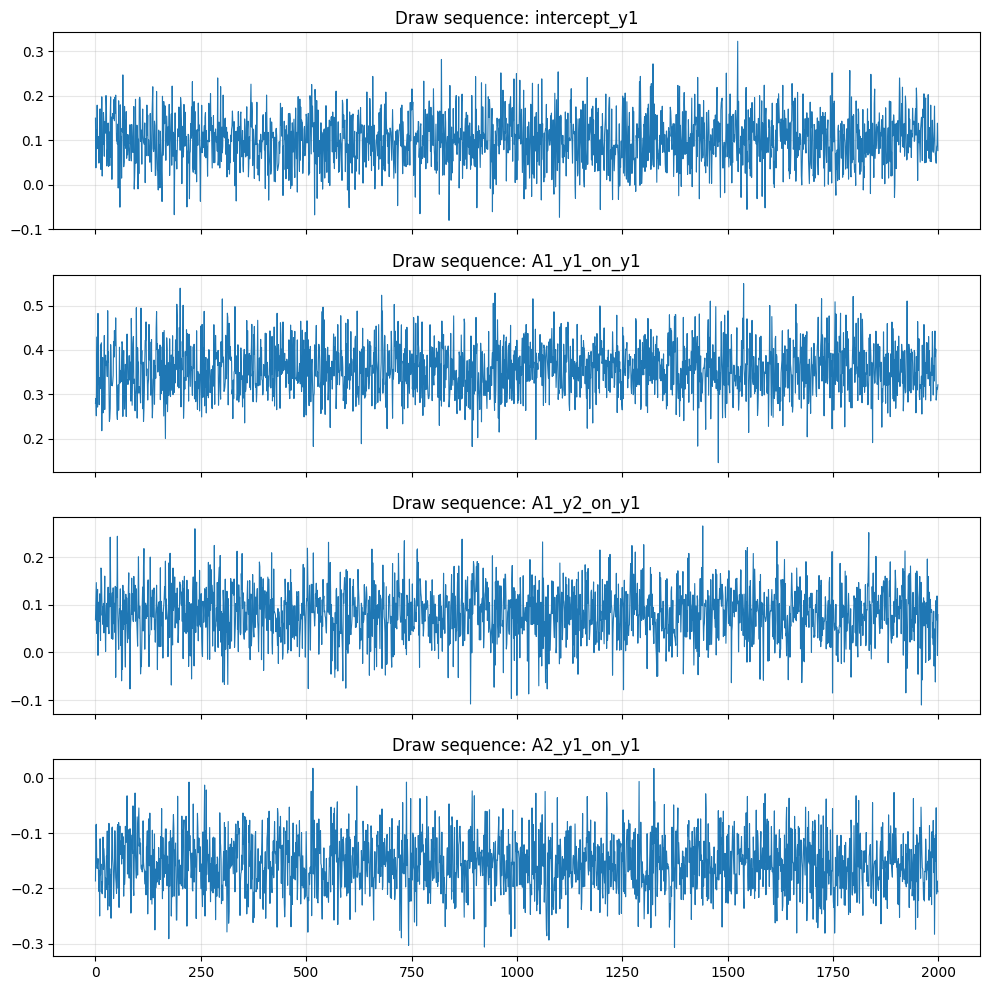

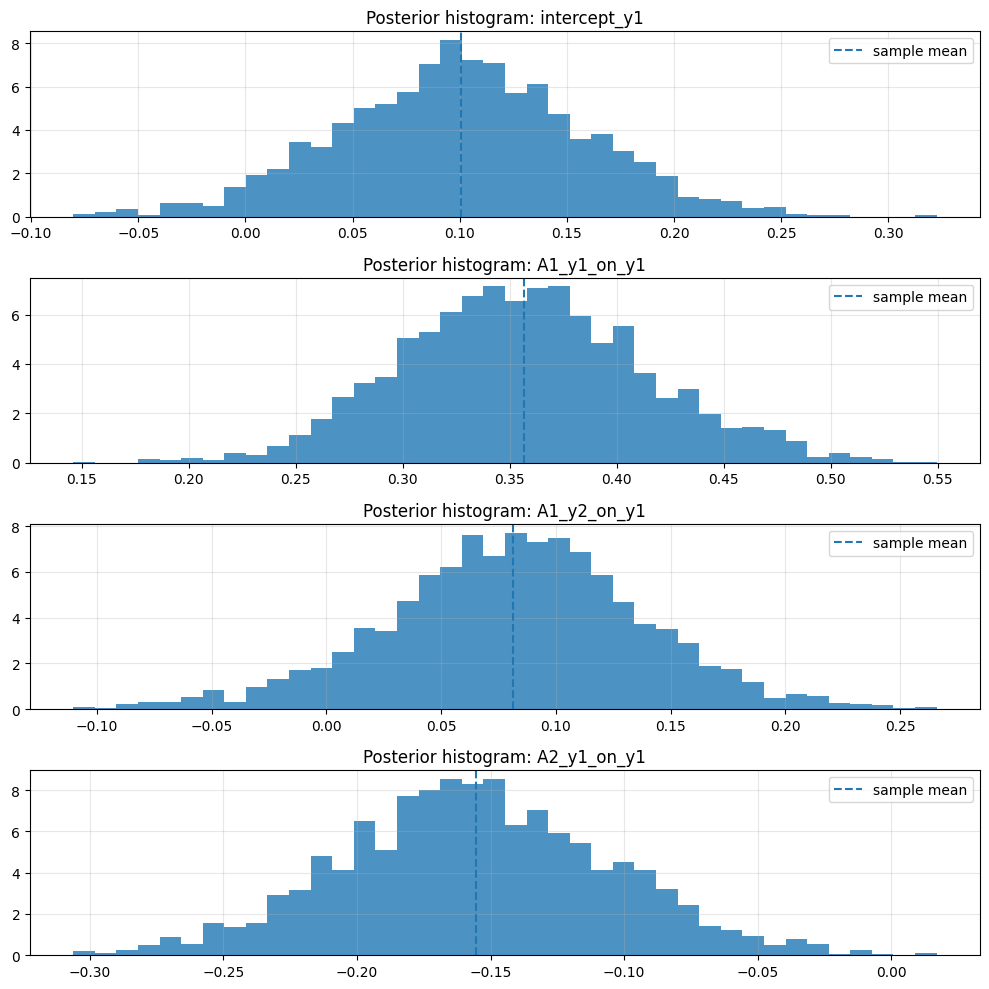

MINNESOTA ESS SUMMARY


,parameter,ESS,draws,ESS_fraction,method
0,intercept_y1,2069.053764,2000,1.034527,arviz
1,A1_y1_on_y1,1945.301349,2000,0.972651,arviz
2,A1_y2_on_y1,1865.545434,2000,0.932773,arviz
3,A2_y1_on_y1,1840.618618,2000,0.920309,arviz


In [31]:
# -----------------------------------------------------------------------------
# Representative Minnesota posterior diagnostic series
# -----------------------------------------------------------------------------
minn_diag_series = {
    "intercept_y1": minn_B_draws[:, 0, 0],
    "A1_y1_on_y1": minn_B_draws[:, 1, 0],   # y1_lag1 -> eq y1
    "A1_y2_on_y1": minn_B_draws[:, 2, 0],   # y2_lag1 -> eq y1
    "A2_y1_on_y1": minn_B_draws[:, 4, 0],   # y1_lag2 -> eq y1
}

print("=" * 80)
print("MINNESOTA POSTERIOR DIAGNOSTIC SERIES")
print("=" * 80)
for name, values in minn_diag_series.items():
    print(
        f"{name:15s} | mean = {values.mean(): .4f} | std = {values.std(ddof=1): .4f} "
        f"| min = {values.min(): .4f} | max = {values.max(): .4f}"
    )

# -----------------------------------------------------------------------------
# Trace-style plots
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(len(minn_diag_series), 1, figsize=(10, 10), sharex=True)

for ax, (name, values) in zip(axes, minn_diag_series.items()):
    ax.plot(values, linewidth=0.8)
    ax.set_title(f"Draw sequence: {name}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Histograms
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(len(minn_diag_series), 1, figsize=(10, 10))

for ax, (name, values) in zip(axes, minn_diag_series.items()):
    ax.hist(values, bins=40, density=True, alpha=0.8)
    ax.axvline(values.mean(), linestyle="--", label="sample mean")
    ax.set_title(f"Posterior histogram: {name}")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# ESS-style summary
# -----------------------------------------------------------------------------
def naive_ess(x, max_lag=200):
    x = np.asarray(x)
    n = len(x)
    x_centered = x - x.mean()
    var = np.dot(x_centered, x_centered) / n

    if var <= 0:
        return float(n)

    autocorrs = []
    for lag in range(1, min(max_lag, n - 1) + 1):
        c = np.dot(x_centered[:-lag], x_centered[lag:]) / n
        rho = c / var
        autocorrs.append(rho)
        if rho < 0:
            break

    tau = 1.0 + 2.0 * np.sum(autocorrs)
    ess = n / tau if tau > 0 else float(n)
    return max(1.0, min(float(n), ess))


ess_rows_minn = []
for name, values in minn_diag_series.items():
    if ARVIZ_AVAILABLE:
        ess_val = float(az.ess(np.asarray(values)))
        method_used = "arviz"
    else:
        ess_val = naive_ess(values)
        method_used = "naive_acf"

    ess_rows_minn.append({
        "parameter": name,
        "ESS": ess_val,
        "draws": len(values),
        "ESS_fraction": ess_val / len(values),
        "method": method_used
    })

ess_minn_df = pd.DataFrame(ess_rows_minn)

print("=" * 80)
print("MINNESOTA ESS SUMMARY")
print("=" * 80)
display(ess_minn_df)

## Minnesota Posterior Predictive Forecasting

With posterior draws from the Minnesota BVAR in hand, we can generate posterior predictive forecasts in the same way as for the NIW BVAR.

For each posterior draw:

1. recover the implied intercept and lag matrices
2. generate an $h$-step forecast path
3. aggregate across draws

This gives:

- posterior predictive mean forecasts
- posterior predictive intervals
- direct comparison against OLS and NIW forecasts

MINNESOTA BVAR POSTERIOR PREDICTIVE FORECASTS
Forecast draws shape: (2000, 10, 3)
Forecast horizon: 10

Posterior predictive mean forecasts:


,y1_mean,y2_mean,y3_mean
1,0.400226,0.344284,0.069178
2,0.070072,0.098630,0.077678
3,0.081759,0.018357,0.035918
4,0.129260,0.005404,0.015815
5,0.138496,0.008154,0.013585
6,0.132355,0.009996,0.014986
7,0.128683,0.009647,0.015397
8,0.128552,0.009009,0.015154
9,0.129102,0.008778,0.014970
10,0.129256,0.008781,0.014941


OLS point forecast from same forecast origin:


,y1_ols,y2_ols,y3_ols
1,0.361628,0.390710,0.093630
2,-0.048046,0.120801,0.105099
3,0.025594,0.007668,0.042330
4,0.141599,-0.013460,0.007836
5,0.160141,0.000854,0.005313
6,0.138073,0.011926,0.011610
7,0.126015,0.013056,0.014503
8,0.127182,0.010986,0.014136
9,0.130513,0.010017,0.013360
10,0.131407,0.010171,0.013185


NIW posterior predictive mean forecasts:


,y1_niw_mean,y2_niw_mean,y3_niw_mean
1,0.364052,0.387945,0.092328
2,-0.043287,0.122712,0.101580
3,0.030156,0.011589,0.040167
4,0.145164,-0.006302,0.006619
5,0.162723,0.007538,0.005767
6,0.139379,0.016787,0.012459
7,0.126906,0.016448,0.014721
8,0.128429,0.013789,0.013638
9,0.131978,0.012810,0.012601
10,0.132669,0.013074,0.012496


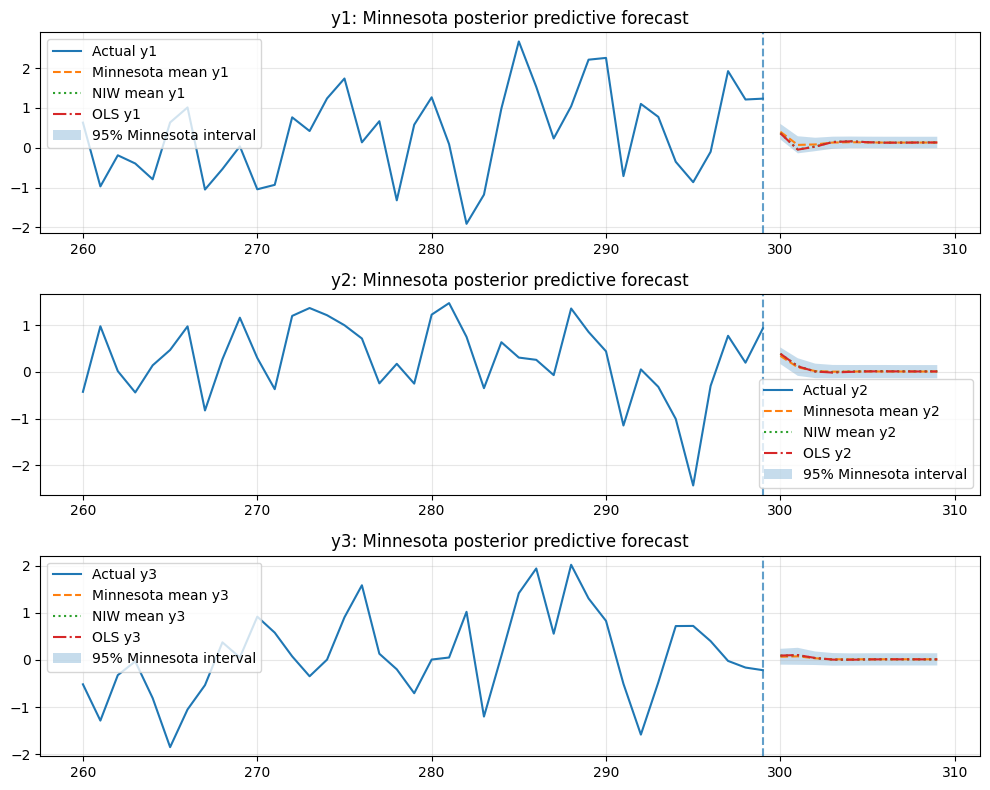

In [32]:
def minnesota_posterior_predictive_draws(B_draws, y_history, p, h, include_intercept=True):
    """
    Compute h-step forecast paths for each posterior draw of the Minnesota BVAR.

    Parameters
    ----------
    B_draws : np.ndarray
        Posterior draws of B, shape (n_draws, m, k)
    y_history : np.ndarray
        Most recent observed history, shape (p, k), ordered oldest -> newest
    p : int
        Lag order
    h : int
        Forecast horizon
    include_intercept : bool
        Whether B includes an intercept row

    Returns
    -------
    forecast_draws : np.ndarray
        Array of shape (n_draws, h, k)
    """
    n_draws, _, k_local = B_draws.shape
    forecast_draws = np.zeros((n_draws, h, k_local))

    for s in range(n_draws):
        intercept_s, A_list_s = extract_var_coefficients(
            B_draws[s],
            k=k_local,
            p=p,
            include_intercept=include_intercept
        )

        forecast_draws[s] = var_forecast(
            A_list=A_list_s,
            intercept=intercept_s,
            y_history=y_history,
            h=h
        )

    return forecast_draws


# -----------------------------------------------------------------------------
# Minnesota posterior predictive example from the end of the sample
# -----------------------------------------------------------------------------
h_minn = 10
y_history = df.values[-p:, :]

minn_forecast_draws = minnesota_posterior_predictive_draws(
    B_draws=minn_B_draws,
    y_history=y_history,
    p=p,
    h=h_minn,
    include_intercept=True
)

minn_forecast_summary = summarize_forecast_draws(
    minn_forecast_draws,
    alpha=0.05
)

print("=" * 80)
print("MINNESOTA BVAR POSTERIOR PREDICTIVE FORECASTS")
print("=" * 80)
print(f"Forecast draws shape: {minn_forecast_draws.shape}")
print(f"Forecast horizon: {h_minn}")
print()

forecast_mean_minn_df = pd.DataFrame(
    minn_forecast_summary["mean"],
    columns=[f"{col}_mean" for col in columns],
    index=np.arange(1, h_minn + 1)
)

print("Posterior predictive mean forecasts:")
display(forecast_mean_minn_df)

# Compare to OLS and NIW from same history
print("OLS point forecast from same forecast origin:")
display(ols_forecast_df)

forecast_mean_niw_df = pd.DataFrame(
    niw_forecast_summary["mean"],
    columns=[f"{col}_niw_mean" for col in columns],
    index=np.arange(1, h_minn + 1)
)

print("NIW posterior predictive mean forecasts:")
display(forecast_mean_niw_df)

# Plot recent history + Minnesota posterior predictive intervals + OLS/NIW mean paths
plot_window = 40
recent_actual = df.iloc[-plot_window:].copy()
future_index = np.arange(recent_actual.index[-1] + 1, recent_actual.index[-1] + h_minn + 1)

fig, axes = plt.subplots(k, 1, figsize=(10, 8), sharex=False)

for j, col in enumerate(columns):
    axes[j].plot(
        recent_actual.index,
        recent_actual[col],
        label=f"Actual {col}"
    )
    axes[j].plot(
        future_index,
        minn_forecast_summary["mean"][:, j],
        linestyle="--",
        label=f"Minnesota mean {col}"
    )
    axes[j].plot(
        future_index,
        niw_forecast_summary["mean"][:, j],
        linestyle=":",
        label=f"NIW mean {col}"
    )
    axes[j].plot(
        future_index,
        ols_forecast_path[:, j],
        linestyle="-.",
        label=f"OLS {col}"
    )
    axes[j].fill_between(
        future_index,
        minn_forecast_summary["lower"][:, j],
        minn_forecast_summary["upper"][:, j],
        alpha=0.25,
        label="95% Minnesota interval"
    )
    axes[j].axvline(recent_actual.index[-1], linestyle="--", alpha=0.7)
    axes[j].set_title(f"{col}: Minnesota posterior predictive forecast")
    axes[j].grid(alpha=0.3)
    axes[j].legend()

plt.tight_layout()
plt.show()

## Rolling Forecast Comparison: OLS, NIW, and Minnesota BVAR

To compare the forecasting behavior of the three models fairly, we run a rolling pseudo out-of-sample experiment.

At each forecast origin:

1. fit the model on the current training sample
2. produce a 1-step-ahead forecast
3. record the realized value
4. repeat until the sample is exhausted

For the Bayesian models, we use posterior draws to compute:

- posterior predictive mean forecast
- 95% predictive interval

We then evaluate:

- RMSE
- MAE
- predictive interval coverage

This gives a direct comparison between:

- OLS VAR
- NIW BVAR
- Minnesota BVAR

ROLLING FORECAST COMPARISON
Training window: 220
Horizon: 1
Bayesian draws per origin: 300



,model,variable,RMSE,MAE,coverage
0,OLS_VAR,y1,1.026098,0.851606,0.9375
1,OLS_VAR,y2,0.930923,0.747469,0.9500
2,OLS_VAR,y3,0.842204,0.679864,0.9625
3,BVAR_NIW,y1,1.025579,0.851017,0.2375
4,BVAR_NIW,y2,0.929866,0.745776,0.2250
5,BVAR_NIW,y3,0.841529,0.678860,0.2125
6,BVAR_Minnesota,y1,1.032166,0.859518,0.1750
7,BVAR_Minnesota,y2,0.911203,0.727573,0.1875
8,BVAR_Minnesota,y3,0.838161,0.673296,0.1875


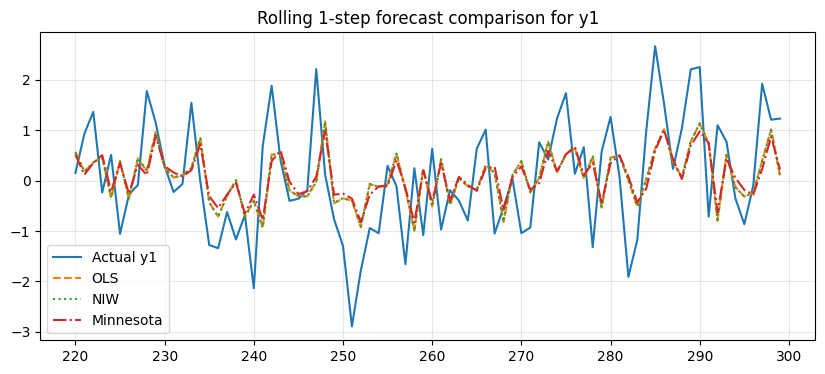

In [33]:
def rolling_ols_forecast(Y, p, train_size, horizon=1, include_intercept=True):
    Y = np.asarray(Y)
    T, k_local = Y.shape
    records = []

    for train_end in range(train_size, T - horizon + 1):
        Y_train = Y[:train_end]
        fit = fit_var_ols(Y_train, p=p, include_intercept=include_intercept)

        y_history = Y_train[-p:, :]
        fcst_path = var_forecast(
            A_list=fit["A_hat_list"],
            intercept=fit["intercept"],
            y_history=y_history,
            h=horizon
        )
        mean_fcst = fcst_path[-1]
        actual = Y[train_end + horizon - 1]

        sigma_diag = np.diag(fit["Sigma_hat"])
        lower_fcst = mean_fcst - 1.96 * np.sqrt(sigma_diag)
        upper_fcst = mean_fcst + 1.96 * np.sqrt(sigma_diag)

        row = {
            "forecast_origin": train_end - 1,
            "target_time": train_end + horizon - 1,
            "model": "OLS_VAR"
        }

        for j in range(k_local):
            row[f"y{j+1}_forecast"] = mean_fcst[j]
            row[f"y{j+1}_actual"] = actual[j]
            row[f"y{j+1}_error"] = mean_fcst[j] - actual[j]
            row[f"y{j+1}_lower"] = lower_fcst[j]
            row[f"y{j+1}_upper"] = upper_fcst[j]
            row[f"y{j+1}_covered"] = int(lower_fcst[j] <= actual[j] <= upper_fcst[j])

        records.append(row)

    return pd.DataFrame(records)


def rolling_niw_bvar_forecast(Y, p, train_size, horizon=1, n_draws=500, include_intercept=True):
    Y = np.asarray(Y)
    T, k_local = Y.shape
    records = []

    for train_end in range(train_size, T - horizon + 1):
        Y_train = Y[:train_end]
        Y_target_train, X_train, _ = build_var_regression_matrices(
            Y_train, p=p, include_intercept=include_intercept
        )

        m = X_train.shape[1]
        prior = make_niw_prior(m=m, k=k_local, prior_var_scale=10.0, sigma_scale=1.0)
        post = compute_niw_posterior(
            Y_target=Y_target_train,
            X=X_train,
            B0=prior["B0"],
            V0=prior["V0"],
            S0=prior["S0"],
            nu0=prior["nu0"]
        )

        draws = sample_niw_posterior_draws(post, n_draws=n_draws, seed=GLOBAL_SEED)
        y_history = Y_train[-p:, :]

        forecast_draws = bvar_posterior_predictive_draws(
            B_draws=draws["B_draws"],
            Sigma_draws=draws["Sigma_draws"],
            y_history=y_history,
            p=p,
            h=horizon,
            include_intercept=include_intercept
        )[:, -1, :]

        mean_fcst = forecast_draws.mean(axis=0)
        lower_fcst = np.quantile(forecast_draws, 0.025, axis=0)
        upper_fcst = np.quantile(forecast_draws, 0.975, axis=0)
        actual = Y[train_end + horizon - 1]

        row = {
            "forecast_origin": train_end - 1,
            "target_time": train_end + horizon - 1,
            "model": "BVAR_NIW"
        }

        for j in range(k_local):
            row[f"y{j+1}_forecast"] = mean_fcst[j]
            row[f"y{j+1}_actual"] = actual[j]
            row[f"y{j+1}_error"] = mean_fcst[j] - actual[j]
            row[f"y{j+1}_lower"] = lower_fcst[j]
            row[f"y{j+1}_upper"] = upper_fcst[j]
            row[f"y{j+1}_covered"] = int(lower_fcst[j] <= actual[j] <= upper_fcst[j])

        records.append(row)

    return pd.DataFrame(records)


def rolling_minnesota_bvar_forecast(Y, p, train_size, horizon=1, n_draws=500, include_intercept=True):
    Y = np.asarray(Y)
    T, k_local = Y.shape
    records = []

    for train_end in range(train_size, T - horizon + 1):
        Y_train = Y[:train_end]

        ols_fit = fit_var_ols(Y_train, p=p, include_intercept=include_intercept)
        minn_fit = fit_bvar_minnesota_posterior_mean(
            Y_train,
            p=p,
            sigma_hat=ols_fit["Sigma_hat"],
            include_intercept=include_intercept,
            lambda1=0.2,
            lambda2=0.5,
            lambda3=1.0,
            intercept_var=1e4,
            stationary_zero_mean=True
        )

        B_draws = sample_minnesota_posterior_draws(
            B_post_mean=minn_fit["B_post_mean"],
            B_post_covs=minn_fit["B_post_covs"],
            n_draws=n_draws,
            seed=GLOBAL_SEED
        )

        y_history = Y_train[-p:, :]
        forecast_draws = minnesota_posterior_predictive_draws(
            B_draws=B_draws,
            y_history=y_history,
            p=p,
            h=horizon,
            include_intercept=include_intercept
        )[:, -1, :]

        mean_fcst = forecast_draws.mean(axis=0)
        lower_fcst = np.quantile(forecast_draws, 0.025, axis=0)
        upper_fcst = np.quantile(forecast_draws, 0.975, axis=0)
        actual = Y[train_end + horizon - 1]

        row = {
            "forecast_origin": train_end - 1,
            "target_time": train_end + horizon - 1,
            "model": "BVAR_Minnesota"
        }

        for j in range(k_local):
            row[f"y{j+1}_forecast"] = mean_fcst[j]
            row[f"y{j+1}_actual"] = actual[j]
            row[f"y{j+1}_error"] = mean_fcst[j] - actual[j]
            row[f"y{j+1}_lower"] = lower_fcst[j]
            row[f"y{j+1}_upper"] = upper_fcst[j]
            row[f"y{j+1}_covered"] = int(lower_fcst[j] <= actual[j] <= upper_fcst[j])

        records.append(row)

    return pd.DataFrame(records)


def compute_forecast_metrics(results_df, k_local):
    rows = []
    model_name = results_df["model"].iloc[0]

    for j in range(1, k_local + 1):
        err = results_df[f"y{j}_error"].values
        coverage = results_df[f"y{j}_covered"].mean()

        rows.append({
            "model": model_name,
            "variable": f"y{j}",
            "RMSE": np.sqrt(np.mean(err**2)),
            "MAE": np.mean(np.abs(err)),
            "coverage": coverage
        })

    return pd.DataFrame(rows)


# -----------------------------------------------------------------------------
# Run rolling comparisons
# -----------------------------------------------------------------------------
train_size_compare = 220
h_compare = 1
n_draws_compare = 300

rolling_ols_results = rolling_ols_forecast(
    df.values, p=p, train_size=train_size_compare, horizon=h_compare
)

rolling_niw_results = rolling_niw_bvar_forecast(
    df.values, p=p, train_size=train_size_compare, horizon=h_compare, n_draws=n_draws_compare
)

rolling_minn_results = rolling_minnesota_bvar_forecast(
    df.values, p=p, train_size=train_size_compare, horizon=h_compare, n_draws=n_draws_compare
)

metrics_ols = compute_forecast_metrics(rolling_ols_results, k)
metrics_niw = compute_forecast_metrics(rolling_niw_results, k)
metrics_minn = compute_forecast_metrics(rolling_minn_results, k)

comparison_metrics = pd.concat([metrics_ols, metrics_niw, metrics_minn], ignore_index=True)

print("=" * 80)
print("ROLLING FORECAST COMPARISON")
print("=" * 80)
print(f"Training window: {train_size_compare}")
print(f"Horizon: {h_compare}")
print(f"Bayesian draws per origin: {n_draws_compare}")
print()

display(comparison_metrics)

# Quick visual comparison for y1
plt.figure(figsize=(10, 4))
plt.plot(rolling_ols_results["target_time"], rolling_ols_results["y1_actual"], label="Actual y1")
plt.plot(rolling_ols_results["target_time"], rolling_ols_results["y1_forecast"], linestyle="--", label="OLS")
plt.plot(rolling_niw_results["target_time"], rolling_niw_results["y1_forecast"], linestyle=":", label="NIW")
plt.plot(rolling_minn_results["target_time"], rolling_minn_results["y1_forecast"], linestyle="-.", label="Minnesota")
plt.title("Rolling 1-step forecast comparison for y1")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Log Predictive Density Comparison Across Models

Point forecast accuracy and interval coverage are useful, but they do not fully evaluate the quality of a predictive distribution.

A more complete probabilistic metric is the **log predictive density**. For each forecast origin, we evaluate the log-density assigned to the realized outcome under the model's predictive distribution.

For the three models in this notebook, we use:

- **OLS VAR**: Gaussian predictive distribution with mean equal to the point forecast and covariance equal to the estimated residual covariance
- **NIW BVAR**: Gaussian approximation using the sample mean and sample covariance of posterior predictive draws
- **Minnesota BVAR**: Gaussian approximation using the sample mean and sample covariance of posterior predictive draws

Higher average log predictive density indicates that the model assigns higher probability to the outcomes that actually occurred.

ROLLING FORECAST COMPARISON WITH LOG PREDICTIVE DENSITY


,model,variable,RMSE,MAE,coverage,avg_log_predictive_density
0,OLS_VAR,y1,1.026098,0.851606,0.9375,-3.937544
1,OLS_VAR,y2,0.930923,0.747469,0.9500,-3.937544
2,OLS_VAR,y3,0.842204,0.679864,0.9625,-3.937544
3,BVAR_NIW,y1,1.025579,0.851017,0.2375,-74.139753
4,BVAR_NIW,y2,0.929866,0.745776,0.2250,-74.139753
5,BVAR_NIW,y3,0.841529,0.678860,0.2125,-74.139753
6,BVAR_Minnesota,y1,1.032166,0.859518,0.1750,-97.931131
7,BVAR_Minnesota,y2,0.911203,0.727573,0.1875,-97.931131
8,BVAR_Minnesota,y3,0.838161,0.673296,0.1875,-97.931131


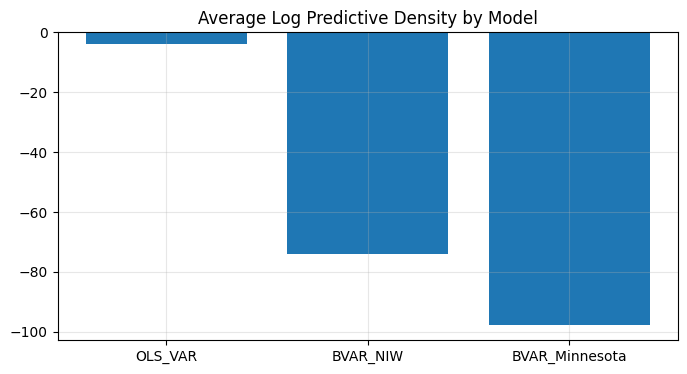

In [34]:
from scipy.stats import multivariate_normal

def rolling_ols_forecast_with_lpd(Y, p, train_size, horizon=1, include_intercept=True):
    Y = np.asarray(Y)
    T, k_local = Y.shape
    records = []

    for train_end in range(train_size, T - horizon + 1):
        Y_train = Y[:train_end]
        fit = fit_var_ols(Y_train, p=p, include_intercept=include_intercept)

        y_history = Y_train[-p:, :]
        fcst_path = var_forecast(
            A_list=fit["A_hat_list"],
            intercept=fit["intercept"],
            y_history=y_history,
            h=horizon
        )
        mean_fcst = fcst_path[-1]
        actual = Y[train_end + horizon - 1]

        Sigma_pred = 0.5 * (fit["Sigma_hat"] + fit["Sigma_hat"].T) + 1e-8 * np.eye(k_local)
        logp = multivariate_normal.logpdf(actual, mean=mean_fcst, cov=Sigma_pred)

        sigma_diag = np.diag(Sigma_pred)
        lower_fcst = mean_fcst - 1.96 * np.sqrt(sigma_diag)
        upper_fcst = mean_fcst + 1.96 * np.sqrt(sigma_diag)

        row = {
            "forecast_origin": train_end - 1,
            "target_time": train_end + horizon - 1,
            "model": "OLS_VAR",
            "log_predictive_density": logp
        }

        for j in range(k_local):
            row[f"y{j+1}_forecast"] = mean_fcst[j]
            row[f"y{j+1}_actual"] = actual[j]
            row[f"y{j+1}_error"] = mean_fcst[j] - actual[j]
            row[f"y{j+1}_lower"] = lower_fcst[j]
            row[f"y{j+1}_upper"] = upper_fcst[j]
            row[f"y{j+1}_covered"] = int(lower_fcst[j] <= actual[j] <= upper_fcst[j])

        records.append(row)

    return pd.DataFrame(records)


def rolling_niw_bvar_forecast_with_lpd(Y, p, train_size, horizon=1, n_draws=500, include_intercept=True):
    Y = np.asarray(Y)
    T, k_local = Y.shape
    records = []

    for train_end in range(train_size, T - horizon + 1):
        Y_train = Y[:train_end]
        Y_target_train, X_train, _ = build_var_regression_matrices(
            Y_train, p=p, include_intercept=include_intercept
        )

        m = X_train.shape[1]
        prior = make_niw_prior(m=m, k=k_local, prior_var_scale=10.0, sigma_scale=1.0)
        post = compute_niw_posterior(
            Y_target=Y_target_train,
            X=X_train,
            B0=prior["B0"],
            V0=prior["V0"],
            S0=prior["S0"],
            nu0=prior["nu0"]
        )

        draws = sample_niw_posterior_draws(post, n_draws=n_draws, seed=GLOBAL_SEED)
        y_history = Y_train[-p:, :]

        forecast_draws = bvar_posterior_predictive_draws(
            B_draws=draws["B_draws"],
            Sigma_draws=draws["Sigma_draws"],
            y_history=y_history,
            p=p,
            h=horizon,
            include_intercept=include_intercept
        )[:, -1, :]

        mean_fcst = forecast_draws.mean(axis=0)
        lower_fcst = np.quantile(forecast_draws, 0.025, axis=0)
        upper_fcst = np.quantile(forecast_draws, 0.975, axis=0)
        actual = Y[train_end + horizon - 1]

        cov_pred = np.cov(forecast_draws.T)
        cov_pred = 0.5 * (cov_pred + cov_pred.T) + 1e-8 * np.eye(k_local)
        logp = multivariate_normal.logpdf(actual, mean=mean_fcst, cov=cov_pred)

        row = {
            "forecast_origin": train_end - 1,
            "target_time": train_end + horizon - 1,
            "model": "BVAR_NIW",
            "log_predictive_density": logp
        }

        for j in range(k_local):
            row[f"y{j+1}_forecast"] = mean_fcst[j]
            row[f"y{j+1}_actual"] = actual[j]
            row[f"y{j+1}_error"] = mean_fcst[j] - actual[j]
            row[f"y{j+1}_lower"] = lower_fcst[j]
            row[f"y{j+1}_upper"] = upper_fcst[j]
            row[f"y{j+1}_covered"] = int(lower_fcst[j] <= actual[j] <= upper_fcst[j])

        records.append(row)

    return pd.DataFrame(records)


def rolling_minnesota_bvar_forecast_with_lpd(Y, p, train_size, horizon=1, n_draws=500, include_intercept=True):
    Y = np.asarray(Y)
    T, k_local = Y.shape
    records = []

    for train_end in range(train_size, T - horizon + 1):
        Y_train = Y[:train_end]

        ols_fit = fit_var_ols(Y_train, p=p, include_intercept=include_intercept)
        minn_fit = fit_bvar_minnesota_posterior_mean(
            Y_train,
            p=p,
            sigma_hat=ols_fit["Sigma_hat"],
            include_intercept=include_intercept,
            lambda1=0.2,
            lambda2=0.5,
            lambda3=1.0,
            intercept_var=1e4,
            stationary_zero_mean=True
        )

        B_draws = sample_minnesota_posterior_draws(
            B_post_mean=minn_fit["B_post_mean"],
            B_post_covs=minn_fit["B_post_covs"],
            n_draws=n_draws,
            seed=GLOBAL_SEED
        )

        y_history = Y_train[-p:, :]
        forecast_draws = minnesota_posterior_predictive_draws(
            B_draws=B_draws,
            y_history=y_history,
            p=p,
            h=horizon,
            include_intercept=include_intercept
        )[:, -1, :]

        mean_fcst = forecast_draws.mean(axis=0)
        lower_fcst = np.quantile(forecast_draws, 0.025, axis=0)
        upper_fcst = np.quantile(forecast_draws, 0.975, axis=0)
        actual = Y[train_end + horizon - 1]

        cov_pred = np.cov(forecast_draws.T)
        cov_pred = 0.5 * (cov_pred + cov_pred.T) + 1e-8 * np.eye(k_local)
        logp = multivariate_normal.logpdf(actual, mean=mean_fcst, cov=cov_pred)

        row = {
            "forecast_origin": train_end - 1,
            "target_time": train_end + horizon - 1,
            "model": "BVAR_Minnesota",
            "log_predictive_density": logp
        }

        for j in range(k_local):
            row[f"y{j+1}_forecast"] = mean_fcst[j]
            row[f"y{j+1}_actual"] = actual[j]
            row[f"y{j+1}_error"] = mean_fcst[j] - actual[j]
            row[f"y{j+1}_lower"] = lower_fcst[j]
            row[f"y{j+1}_upper"] = upper_fcst[j]
            row[f"y{j+1}_covered"] = int(lower_fcst[j] <= actual[j] <= upper_fcst[j])

        records.append(row)

    return pd.DataFrame(records)


def summarize_lpd_and_metrics(results_df, k_local):
    rows = []
    model_name = results_df["model"].iloc[0]

    for j in range(1, k_local + 1):
        err = results_df[f"y{j}_error"].values
        coverage = results_df[f"y{j}_covered"].mean()

        rows.append({
            "model": model_name,
            "variable": f"y{j}",
            "RMSE": np.sqrt(np.mean(err**2)),
            "MAE": np.mean(np.abs(err)),
            "coverage": coverage,
            "avg_log_predictive_density": results_df["log_predictive_density"].mean()
        })

    return pd.DataFrame(rows)


# -----------------------------------------------------------------------------
# Run rolling comparison with LPD
# -----------------------------------------------------------------------------
rolling_ols_lpd = rolling_ols_forecast_with_lpd(
    df.values, p=p, train_size=train_size_compare, horizon=h_compare
)

rolling_niw_lpd = rolling_niw_bvar_forecast_with_lpd(
    df.values, p=p, train_size=train_size_compare, horizon=h_compare, n_draws=n_draws_compare
)

rolling_minn_lpd = rolling_minnesota_bvar_forecast_with_lpd(
    df.values, p=p, train_size=train_size_compare, horizon=h_compare, n_draws=n_draws_compare
)

summary_ols_lpd = summarize_lpd_and_metrics(rolling_ols_lpd, k)
summary_niw_lpd = summarize_lpd_and_metrics(rolling_niw_lpd, k)
summary_minn_lpd = summarize_lpd_and_metrics(rolling_minn_lpd, k)

comparison_lpd = pd.concat(
    [summary_ols_lpd, summary_niw_lpd, summary_minn_lpd],
    ignore_index=True
)

print("=" * 80)
print("ROLLING FORECAST COMPARISON WITH LOG PREDICTIVE DENSITY")
print("=" * 80)
display(comparison_lpd)

avg_lpd_by_model = (
    comparison_lpd[["model", "avg_log_predictive_density"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 4))
plt.bar(avg_lpd_by_model["model"], avg_lpd_by_model["avg_log_predictive_density"])
plt.title("Average Log Predictive Density by Model")
plt.grid(alpha=0.3, axis="y")
plt.show()

## Experiment Logging and Export for the BVAR Notebook

To make the notebook reproducible and easy to compare against future extensions, we save:

1. a compact JSON summary of the experiment
2. a serialized experiment object containing fitted outputs and forecast results

This mirrors the VAR notebook and makes later comparisons easier for:

- Gaussian BVARs
- non-Gaussian innovation models
- diffusion-based residual models
- DRO forecast layers

We save logs to a `logs/` folder so the notebook remains organized and results can be versioned outside source code.

In [35]:
import json
import pickle
from pathlib import Path
from datetime import datetime

# -----------------------------------------------------------------------------
# Logging utilities
# -----------------------------------------------------------------------------
def summarize_bvar_experiment(
    model_name,
    df,
    p,
    train_size,
    horizon,
    n_draws,
    metrics_df,
    extra_config=None
):
    timestamp = datetime.now()

    summary = {
        "timestamp_iso": timestamp.isoformat(timespec="seconds"),
        "timestamp_unix": timestamp.timestamp(),
        "model_name": model_name,
        "n_obs": int(df.shape[0]),
        "n_vars": int(df.shape[1]),
        "lag_order_p": int(p),
        "train_size": int(train_size),
        "forecast_horizon": int(horizon),
        "posterior_draws_per_origin": int(n_draws),
        "metrics": metrics_df.to_dict(orient="records"),
    }

    if extra_config is not None:
        summary["extra_config"] = extra_config

    return summary


def save_json_log(summary, save_dir="logs"):
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"{summary['model_name']}_{timestamp}.json"
    filepath = save_path / filename

    with open(filepath, "w") as f:
        json.dump(summary, f, indent=2)

    return filepath


def export_bvar_experiment(
    filename,
    df,
    p,
    niw_post,
    niw_draws,
    minn_results,
    minn_B_draws,
    rolling_ols_results,
    rolling_niw_results,
    rolling_minn_results,
    comparison_metrics,
    comparison_lpd
):
    experiment = {
        "timestamp_iso": datetime.now().isoformat(timespec="seconds"),
        "data": df,
        "config": {
            "lag_order": p,
            "n_variables": df.shape[1],
            "n_observations": df.shape[0]
        },
        "niw": {
            "posterior_hyperparameters": niw_post,
            "draws": {
                "B_draws": niw_draws["B_draws"],
                "Sigma_draws": niw_draws["Sigma_draws"]
            }
        },
        "minnesota": {
            "posterior_mean_results": minn_results,
            "draws": {
                "B_draws": minn_B_draws
            }
        },
        "rolling_results": {
            "ols": rolling_ols_results,
            "niw": rolling_niw_results,
            "minnesota": rolling_minn_results
        },
        "comparison_metrics": comparison_metrics,
        "comparison_lpd": comparison_lpd
    }

    save_dir = Path("logs")
    save_dir.mkdir(parents=True, exist_ok=True)

    filepath = save_dir / filename
    with open(filepath, "wb") as f:
        pickle.dump(experiment, f)

    return filepath


# -----------------------------------------------------------------------------
# Build and save summaries
# -----------------------------------------------------------------------------
summary_niw = summarize_bvar_experiment(
    model_name="BVAR_NIW",
    df=df,
    p=p,
    train_size=train_size_compare,
    horizon=h_compare,
    n_draws=n_draws_compare,
    metrics_df=summary_niw_lpd,
    extra_config={
        "prior": "Normal-Inverse-Wishart",
        "global_seed": GLOBAL_SEED
    }
)

summary_minn = summarize_bvar_experiment(
    model_name="BVAR_Minnesota",
    df=df,
    p=p,
    train_size=train_size_compare,
    horizon=h_compare,
    n_draws=n_draws_compare,
    metrics_df=summary_minn_lpd,
    extra_config={
        "prior": "Minnesota",
        "lambda1": 0.2,
        "lambda2": 0.5,
        "lambda3": 1.0,
        "intercept_var": 1e4,
        "global_seed": GLOBAL_SEED
    }
)

niw_log_path = save_json_log(summary_niw, save_dir="logs")
minn_log_path = save_json_log(summary_minn, save_dir="logs")

bvar_export_path = export_bvar_experiment(
    filename="bvar_mechanics_experiment.pkl",
    df=df,
    p=p,
    niw_post=niw_post,
    niw_draws=niw_draws,
    minn_results=minn_results,
    minn_B_draws=minn_B_draws,
    rolling_ols_results=rolling_ols_lpd,
    rolling_niw_results=rolling_niw_lpd,
    rolling_minn_results=rolling_minn_lpd,
    comparison_metrics=comparison_metrics,
    comparison_lpd=comparison_lpd
)

print("=" * 80)
print("BVAR LOGGING AND EXPORT COMPLETE")
print("=" * 80)
print(f"Saved NIW JSON log: {niw_log_path}")
print(f"Saved Minnesota JSON log: {minn_log_path}")
print(f"Saved BVAR experiment object: {bvar_export_path}")
print()

print("NIW summary preview:")
print(json.dumps(summary_niw, indent=2)[:1200], "...\n")

print("Minnesota summary preview:")
print(json.dumps(summary_minn, indent=2)[:1200], "...")

BVAR LOGGING AND EXPORT COMPLETE
Saved NIW JSON log: logs/BVAR_NIW_20260315_175241.json
Saved Minnesota JSON log: logs/BVAR_Minnesota_20260315_175241.json
Saved BVAR experiment object: logs/bvar_mechanics_experiment.pkl

NIW summary preview:
{
  "timestamp_iso": "2026-03-15T17:52:41",
  "timestamp_unix": 1773611561.60805,
  "model_name": "BVAR_NIW",
  "n_obs": 300,
  "n_vars": 3,
  "lag_order_p": 2,
  "train_size": 220,
  "forecast_horizon": 1,
  "posterior_draws_per_origin": 300,
  "metrics": [
    {
      "model": "BVAR_NIW",
      "variable": "y1",
      "RMSE": 1.0255791282709936,
      "MAE": 0.8510171887666557,
      "coverage": 0.2375,
      "avg_log_predictive_density": -74.13975286642848
    },
    {
      "model": "BVAR_NIW",
      "variable": "y2",
      "RMSE": 0.9298659848660995,
      "MAE": 0.7457764316072419,
      "coverage": 0.225,
      "avg_log_predictive_density": -74.13975286642848
    },
    {
      "model": "BVAR_NIW",
      "variable": "y3",
      "RMSE": 0.841